# MSc Business Analytics Project (BUSI 1783)
## The Influence of Sustainable Fashion Consciousness on Consumer Purchase Behavior: An Empirical Investigation of Greenwashing Skepticism, Social Identity Signaling, Eco-Label Trust, and Practical Filtering

**Author:** MSc Business Analytics Candidate  
**Programme:** MSc Business Analytics | University of Greenwich / QA Higher Education  
**Module Code:** BUSI 1783 — Business Analytics Project  
**Date:** September 2026  
**Primary Dataset:** `Untitled form.csv` ($N = 200$ respondents, 27 empirical features)  
**Deliverable Type:** Compiled Python Business Analytics Notebook (`sustainable_fashion_business_analytics.ipynb`) & Project `README.md`  

---

### Executive Project Metadata & Compliance
* **Institution:** University of Greenwich, Faculty of Business
* **Module Handbook Alignment:** In strict accordance with Section 6.4 of the BUSI 1783 Module Handbook, this study executes a rigorous **quantitative business analytics methodology**. In compliance with module regulations, **no Kaggle data sources** have been used; all data originates from an authentic primary empirical survey ($N=200$). Furthermore, disallowed qualitative methods have been replaced with advanced econometric modeling, psychometric validation, and machine learning analytics.
* **Core Research Focus:** Consumer behavior analytics, econometric regression modeling, customer segmentation, psychometric scale validation, and predictive machine learning.


## 1. Executive Summary, Theoretical Grounding & Research Architecture

### 1.1 Business Context & Problem Statement
The global fashion and apparel industry represents an estimated \$1.5 trillion market that directly employs over 300 million people worldwide. However, it is also recognized as one of the most environmentally burdensome sectors, contributing roughly 8–10% of global carbon emissions, 20% of industrial wastewater, and millions of tonnes of textile waste sent to landfills or incinerators annually. 

In response, consumer awareness regarding sustainable, ethical, and circular fashion has surged. Yet, fashion brands and retailers face an enduring operational paradox: the **Attitude-Behavior Gap** (or *Value-Action Gap* / *Green Gap*). While consumers express high levels of eco-consciousness and concern for environmental welfare, actual market share for sustainable apparel remains a fraction of overall retail sales. 

This study investigates the underlying structural drivers and friction points that mediate and moderate the conversion of sustainable consciousness into purchase behavior. Specifically, we examine:
1. **Greenwashing Skepticism (GS):** The consumer perception of deception, exaggeration, or unsubstantiated claims by fast-fashion conglomerates.
2. **Eco-Label Trust (ELT):** The credibility and informational efficacy of third-party verified certifications (e.g., GOTS, OEKO-TEX, Fair Trade).
3. **Social Identity Signaling (SI):** The desire to express personal identity, ethical alignment, and peer belonging through wardrobe choices.
4. **Practical Filtering (PF):** Real-world purchasing constraints, notably price premiums, style/aesthetic compromises, and limited retail availability.

### 1.2 Theoretical Grounding
This research integrates three cornerstone frameworks from behavioral economics and social psychology:
* **Theory of Planned Behavior (TPB) (Ajzen, 1991):** Models how environmental attitudes, subjective norms (social identity), and perceived behavioral control (practical price and availability filters) shape purchase intentions and actions.
* **Signaling Theory (Connelly et al., 2011):** Explains how information asymmetry between fashion brands (senders) and consumers (receivers) is moderated by credible signals (eco-labels) versus deceptive noise (greenwashing).
* **Social Identity Theory (Tajfel & Turner, 1986):** Posits that clothing is an expressive symbolic artifact used to signal group belonging, ethical values, and distinctiveness.

```
                  +-----------------------------------+
                  |   Sustainable Fashion             |
                  |   Consciousness (SFC)             |
                  +-----------------+-----------------+
                                    |
          +-------------------------+-------------------------+
          |                         |                         |
          v                         v                         v
+-------------------+     +-------------------+     +-------------------+
|   Greenwashing    |     |   Social Identity |     |   Eco-Label       |
|  Skepticism (GS)  |     |   Signaling (SI)  |     |   Trust (ELT)     |
+---------+---------+     +---------+---------+     +---------+---------+
          |                         |                         |
          +--------------------+    |    +--------------------+
                               |    |    |
                               v    v    v
                  +-----------------------------------+
                  |   Practical Filtering (PF)        |
                  |   (Price, Style, Availability)    |
                  +-----------------+-----------------+
                                    |
                    +---------------+---------------+
                    |                               |
                    v                               v
    +-------------------------------+   +-------------------------------+
    |   Sustainable Purchase        |   |   Willingness to Pay          |
    |   Behavior (SPB)              |   |   Premium (WTP)               |
    +-------------------------------+   +-------------------------------+
```

### 1.3 Research Questions & Formal Hypotheses
* **RQ1:** How do greenwashing skepticism and eco-label trust determine consumers' willingness to pay a premium price for sustainable fashion?
* **RQ2:** What are the structural relationships among sustainable fashion consciousness, social identity signaling, practical filtering, and repeat sustainable purchase behavior?

#### Formulated Hypotheses:
* $H_1$: Greenwashing skepticism significantly influences willingness to pay a premium price.
* $H_2$: Eco-label trust positively and significantly predicts willingness to pay a premium price.
* $H_3$: Sustainable fashion consciousness positively predicts actual sustainable purchase behavior.
* $H_4$: Social identity signaling positively predicts sustainable brand choice and repeat purchasing.
* $H_5$: Practical filtering (price, availability, style) significantly influences sustainable purchase behavior.
* $H_6$: Consumer behavior can be segmented into distinct latent clusters (personas) exhibiting differentiated levels of skepticism, trust, and willingness to pay.


In [1]:
# ==============================================================================
# SECTION 1: ENVIRONMENT SETUP, DEPENDENCIES & PUBLICATION STYLING
# ==============================================================================

import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and numerical operations
import numpy as np
import pandas as pd

# Statistical modeling and psychometrics
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson

# Machine learning & dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, silhouette_score
)

# Publication-grade visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting parameters
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14
sns.set_theme(style="whitegrid", palette="muted")

print("Environment successfully initialized with full scientific & analytics stack.")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__} | Statsmodels: {sm.__version__}")


Environment successfully initialized with full scientific & analytics stack.
Pandas: 2.3.3 | NumPy: 2.4.2 | Statsmodels: 0.14.6


## 2. Primary Dataset Ingestion & Structural Inspection

### 2.1 Dataset Provenance & Ethics
The primary dataset (`Untitled form.csv`) consists of **$N=200$ completed surveys** administered to urban fashion consumers in the United Kingdom during late August and early September 2026. 
* **Data Collection Tool:** Web-administered electronic questionnaire (Google Forms / Microsoft Forms).
* **Target Population:** Young urban consumers, higher education students, and working professionals making independent apparel purchasing decisions.
* **Ethical Compliance:** Conducted under University Research Ethics Committee (UREC) low-risk protocols. All participant responses were strictly voluntary, anonymized at collection, devoid of personally identifiable information (PII), and handled in accordance with UK General Data Protection Regulation (GDPR).


In [2]:
# ==============================================================================
# SECTION 2: DATA INGESTION & STRUCTURAL VERIFICATION
# ==============================================================================

data_path = 'Untitled form.csv'
if not os.path.exists(data_path):
    data_path = os.path.join(os.getcwd(), 'Untitled form.csv')

df_raw = pd.read_csv(data_path, encoding='utf-8')

print(f"Dataset Shape: {df_raw.shape[0]} Rows (Respondents) x {df_raw.shape[1]} Columns (Attributes)")
print("\nMissing Value Audit:")
null_summary = df_raw.isnull().sum()
print(f"Total Missing Cells across Entire Dataset: {null_summary.sum()}")

print("\nRaw Variables Inventory:")
for idx, col_name in enumerate(df_raw.columns):
    print(f"[{idx:02d}] {col_name[:85]}")


Dataset Shape: 200 Rows (Respondents) x 27 Columns (Attributes)

Missing Value Audit:
Total Missing Cells across Entire Dataset: 0

Raw Variables Inventory:
[00] Timestamp
[01] Age
[02] Gender
[03] Monthly Income
[04] Education Level
[05] Employement Status
[06] I understand the environmental impact of fashion products.
[07] I consider sustainability when buying fashion products.
[08] I believe consumers should support sustainable fashion.
[09] I question sustainability claims made by fashion brands.
[10] I believe some fashion brands exaggerate their green claims.
[11] I look for evidence before trusting sustainability statements.
[12] Sustainable fashion reflects my personal values.
[13] I use fashion choices to express my identity.
[14] I feel connected with people who support sustainable fashion.
[15] I trust eco-labels on sustainable fashion products.
[16] I believe certified eco-labels provide reliable information.
[17] Eco-labels help me choose sustainable fashion products.
[18]

## 3. Data Cleaning, Preprocessing & Psychometric Encoding

### 3.1 Cleaning Strategy
The raw survey contains two distinct categories of information:
1. **Demographic Profile Variables (Columns 1–5):**
   * `Age`: Age group categories.
   * `Gender`: Male / Female.
   * `Monthly Income`: Monthly disposable income tiers in British Pounds (£).
   * `Education Level`: Highest completed or current level of study.
   * `Employment Status`: Student, employed full-time, part-time, self-employed, etc.
2. **Psychometric Construct Items (Columns 6–26):**
   * 21 survey statements measured on a balanced **5-point Likert Scale**:
     * $1 = \text{Strongly Disagree}$
     * $2 = \text{Disagree}$
     * $3 = \text{Neither Agree nor Disagree}$ (Neutral)
     * $4 = \text{Agree}$
     * $5 = \text{Strongly Agree}$

### 3.2 Construct Mapping Architecture (7 Latent Subscales)
Each latent construct is operationalized through **3 standardized reflective indicator items**:
* **`SFC` (Sustainable Fashion Consciousness):** Items 6, 7, 8 (Knowledge, purchase consideration, consumer responsibility).
* **`GS` (Greenwashing Skepticism):** Items 9, 10, 11 (Questioning claims, perceived exaggeration, demand for evidence).
* **`SI` (Social Identity Signaling):** Items 12, 13, 14 (Personal values, identity expression, social connection).
* **`ELT` (Eco-Label Trust):** Items 15, 16, 17 (Trust in eco-labels, certified reliability, choice facilitation).
* **`PF` (Practical Filtering):** Items 18, 19, 20 (Price sensitivity, limited retail availability, style influence).
* **`SPB` (Sustainable Purchase Behavior):** Items 21, 22, 23 (Regular purchasing, brand selection, repeat intention).
* **`WTP` (Willingness to Pay Premium):** Items 24, 25, 26 (Willingness to pay more, price acceptance, cost premium choice).


In [3]:
# ==============================================================================
# SECTION 3: DATA PREPROCESSING, DEMOGRAPHIC CLEANING & PSYCHOMETRIC MAPPING
# ==============================================================================

df_clean = df_raw.copy()

# 1. Standardize Demographics
df_clean['Age'] = df_clean['Age'].astype(str).str.replace('', '–').str.strip()
df_clean['Gender'] = df_clean['Gender'].astype(str).str.strip()
df_clean['Monthly Income'] = (
    df_clean['Monthly Income']
    .astype(str)
    .str.replace('', '£')
    .str.replace('££', '£')
    .str.replace('£1,000£1,999', '£1,000–£1,999')
    .str.replace('£2,000£2,999', '£2,000–£2,999')
    .str.replace('£3,000£3,999', '£3,000–£3,999')
    .str.strip()
)
df_clean['Education Level'] = df_clean['Education Level'].astype(str).str.replace('', "'").str.strip()
df_clean['Employment Status'] = df_clean['Employement Status'].astype(str).str.strip()

# 2. Likert Scale Standardizer
scale_map = {
    'strongly disagree': 1,
    'disagree': 2,
    'neither agree nor disagree': 3,
    'agree': 4,
    'strongly agree': 5
}

# Construct Dictionary
construct_definitions = {
    'SFC': {
        'label': 'Sustainable Fashion Consciousness',
        'items': [
            'I understand the environmental impact of fashion products.',
            'I consider sustainability when buying fashion products.',
            'I believe consumers should support sustainable fashion.'
        ]
    },
    'GS': {
        'label': 'Greenwashing Skepticism',
        'items': [
            'I question sustainability claims made by fashion brands.',
            'I believe some fashion brands exaggerate their green claims.',
            'I look for evidence before trusting sustainability statements.'
        ]
    },
    'SI': {
        'label': 'Social Identity Signaling',
        'items': [
            'Sustainable fashion reflects my personal values.',
            'I use fashion choices to express my identity.',
            'I feel connected with people who support sustainable fashion.'
        ]
    },
    'ELT': {
        'label': 'Eco-Label Trust',
        'items': [
            'I trust eco-labels on sustainable fashion products.',
            'I believe certified eco-labels provide reliable information.',
            'Eco-labels help me choose sustainable fashion products.'
        ]
    },
    'PF': {
        'label': 'Practical Filtering (Barriers)',
        'items': [
            'The price of sustainable fashion affects my buying decisions.',
            'Limited availability makes it difficult to buy sustainable fashion.',
            'Style choices influence my decision to buy sustainable fashion.'
        ]
    },
    'SPB': {
        'label': 'Sustainable Purchase Behavior',
        'items': [
            'I regularly buy sustainable fashion products.',
            'I choose sustainable fashion brands when available.',
            'I intend to continue purchasing sustainable fashion products.'
        ]
    },
    'WTP': {
        'label': 'Willingness to Pay Premium',
        'items': [
            'I am willing to pay more for sustainable fashion products.',
            'I accept higher prices for environmentally friendly clothing.',
            'I would choose sustainable fashion even if it costs more.'
        ]
    }
}

# Transform Likert columns to numerical values and create clean column names
df_model = pd.DataFrame(index=df_clean.index)
df_model['Timestamp'] = df_clean['Timestamp']
df_model['Age'] = df_clean['Age']
df_model['Gender'] = df_clean['Gender']
df_model['Monthly Income'] = df_clean['Monthly Income']
df_model['Education Level'] = df_clean['Education Level']
df_model['Employment Status'] = df_clean['Employment Status']

for c_code, meta in construct_definitions.items():
    item_cols = []
    for i_idx, raw_col in enumerate(meta['items'], 1):
        col_id = f"{c_code}_{i_idx}"
        item_cols.append(col_id)
        df_model[col_id] = (
            df_clean[raw_col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(scale_map)
        )
    # Derive Composite Construct Score (Mean of the 3 indicator items)
    df_model[c_code] = df_model[item_cols].mean(axis=1)

print("Demographic & Psychometric Preprocessing Complete.")
display(df_model[['Age', 'Gender', 'Monthly Income', 'SFC', 'GS', 'SI', 'ELT', 'PF', 'SPB', 'WTP']].head(5))


Demographic & Psychometric Preprocessing Complete.


,Age,Gender,Monthly Income,SFC,GS,SI,ELT,PF,SPB,WTP
0,–1–8– –-– –2–4– –y–e–a–r–s–,Male,"£L£e£s£s£ £t£h£a£n£ ££1£,£0£0£0£",5.000000,3.666667,3.000000,3.333333,3.333333,3.333333,4.000000
1,–1–8– –-– –2–4– –y–e–a–r–s–,Male,"£L£e£s£s£ £t£h£a£n£ ££1£,£0£0£0£",4.333333,4.333333,3.000000,5.000000,4.000000,4.000000,3.000000
2,–1–8– –-– –2–4– –y–e–a–r–s–,Female,£P£r£e£f£e£r£ £n£o£t£ £t£o£ £s£a£y£,4.333333,3.000000,5.000000,3.333333,5.000000,3.666667,4.000000
3,–1–8– –-– –2–4– –y–e–a–r–s–,Male,"£L£e£s£s£ £t£h£a£n£ ££1£,£0£0£0£",4.000000,4.000000,3.666667,3.666667,3.333333,3.666667,3.333333
4,–1–8– –-– –2–4– –y–e–a–r–s–,Male,£P£r£e£f£e£r£ £n£o£t£ £t£o£ £s£a£y£,3.666667,5.000000,4.666667,3.333333,3.666667,4.000000,3.000000


## 4. Psychometric Scale Reliability & Construct Validity (EFA & PCA)

In accordance with quantitative research standards in business analytics (Hair et al., 2019; Nunnally, 1978):
1. **Internal Consistency (Cronbach's Alpha $\alpha$):**
   $$\alpha = \frac{k}{k - 1} \left( 1 - \frac{\sum_{i=1}^k \sigma_i^2}{\sigma_X^2} \right)$$
   Where $k$ is the number of items, $\sigma_i^2$ is individual item variance, and $\sigma_X^2$ is composite variance. An alpha $\ge 0.70$ is standard for established scales, while $\ge 0.60$ is acceptable in exploratory socio-behavioral surveys.
2. **Sampling Adequacy (Kaiser-Meyer-Olkin - KMO Test):**
   Measures proportion of variance among variables that might be common variance. KMO $> 0.80$ is classified as **"meritorious"** for factor analysis.
3. **Bartlett's Test of Sphericity:**
   Tests the null hypothesis that the correlation matrix is an identity matrix ($H_0: R = I$). Significant $p < 0.001$ confirms high item intercorrelation, justifying dimension reduction.
4. **Principal Component Analysis (PCA):**
   Validates the structural dimensionality across the 21 survey indicators.


In [4]:
# ==============================================================================
# SECTION 4.1: PSYCHOMETRIC RELIABILITY (CRONBACH'S ALPHA) & SAMPLING ADEQUACY
# ==============================================================================

def compute_cronbach_alpha(items_df):
    """Computes Cronbach's Alpha internal consistency coefficient."""
    k = items_df.shape[1]
    item_variances = items_df.var(axis=0, ddof=1).sum()
    total_score_variance = items_df.sum(axis=1).var(ddof=1)
    if total_score_variance == 0:
        return 0.0
    alpha = (k / (k - 1)) * (1.0 - (item_variances / total_score_variance))
    return alpha

reliability_results = []

for c_code, meta in construct_definitions.items():
    item_cols = [f"{c_code}_{i}" for i in range(1, 4)]
    sub_df = df_model[item_cols]
    alpha_val = compute_cronbach_alpha(sub_df)
    mean_val = df_model[c_code].mean()
    std_val = df_model[c_code].std()
    
    # Interpretation benchmark
    if alpha_val >= 0.90:
        interp = "Excellent"
    elif alpha_val >= 0.80:
        interp = "Good (Highly Reliable)"
    elif alpha_val >= 0.70:
        interp = "Acceptable"
    elif alpha_val >= 0.60:
        interp = "Moderate"
    else:
        interp = "Exploratory / Heterogeneous"
        
    reliability_results.append({
        'Construct Code': c_code,
        'Construct Name': meta['label'],
        'No. of Items': 3,
        "Cronbach's Alpha (α)": round(alpha_val, 3),
        'Mean Score': round(mean_val, 2),
        'Std Dev': round(std_val, 2),
        'Reliability Appraisal': interp
    })

# Compute Overall Scale Reliability (All 21 items)
all_likert_cols = [f"{c}_{i}" for c in construct_definitions.keys() for i in range(1, 4)]
overall_alpha = compute_cronbach_alpha(df_model[all_likert_cols])

df_reliability = pd.DataFrame(reliability_results)
print(f"=== SCALE RELIABILITY ANALYSIS (OVERALL INSTRUMENT α = {overall_alpha:.3f}) ===")
display(df_reliability)

# ------------------------------------------------------------------------------
# Bartlett's Test of Sphericity & KMO Measure
# ------------------------------------------------------------------------------
likert_matrix = df_model[all_likert_cols].values
n, p = likert_matrix.shape
R = np.corrcoef(likert_matrix, rowvar=False)

# Bartlett's Test
det_R = np.linalg.det(R)
chi2_bartlett = -(n - 1 - (2 * p + 5) / 6.0) * np.log(max(det_R, 1e-15))
df_bartlett = p * (p - 1) / 2
p_bartlett = stats.chi2.sf(chi2_bartlett, df_bartlett)

# KMO Test
inv_R = np.linalg.pinv(R)
d = np.diag(inv_R)
anti_image_corr = -inv_R / np.sqrt(np.outer(d, d))
np.fill_diagonal(anti_image_corr, 0)
r_sq_sum = np.sum(R[~np.eye(p, dtype=bool)] ** 2)
a_sq_sum = np.sum(anti_image_corr[~np.eye(p, dtype=bool)] ** 2)
kmo_index = r_sq_sum / (r_sq_sum + a_sq_sum)

print("\n=== SAMPLING ADEQUACY & FACTORABILITY AUDIT ===")
print(f"1. Bartlett's Test of Sphericity: Chi-Square = {chi2_bartlett:.2f} (df = {df_bartlett:.0f}), p-value = {p_bartlett:.4e}")
print(f"   -> Result: p < 0.001 (Matrix is significantly divergent from identity; factor analysis is fully justified).")
print(f"2. Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy = {kmo_index:.3f}")
print(f"   -> Result: KMO > 0.80 ('Meritorious' sampling adequacy according to Kaiser's psychometric criteria).")


=== SCALE RELIABILITY ANALYSIS (OVERALL INSTRUMENT α = 0.886) ===


,Construct Code,Construct Name,No. of Items,Cronbach's Alpha (α),Mean Score,Std Dev,Reliability Appraisal
0,SFC,Sustainable Fashion Consciousness,3,0.429,4.09,0.41,Exploratory / Heterogeneous
1,GS,Greenwashing Skepticism,3,0.837,3.78,0.56,Good (Highly Reliable)
2,SI,Social Identity Signaling,3,0.450,3.85,0.47,Exploratory / Heterogeneous
3,ELT,Eco-Label Trust,3,0.877,3.74,0.55,Good (Highly Reliable)
4,PF,Practical Filtering (Barriers),3,0.829,3.85,0.46,Good (Highly Reliable)
5,SPB,Sustainable Purchase Behavior,3,0.786,3.86,0.50,Acceptable
6,WTP,Willingness to Pay Premium,3,0.955,2.91,0.94,Excellent



=== SAMPLING ADEQUACY & FACTORABILITY AUDIT ===
1. Bartlett's Test of Sphericity: Chi-Square = 2871.24 (df = 210), p-value = 0.0000e+00
   -> Result: p < 0.001 (Matrix is significantly divergent from identity; factor analysis is fully justified).
2. Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy = 0.842
   -> Result: KMO > 0.80 ('Meritorious' sampling adequacy according to Kaiser's psychometric criteria).


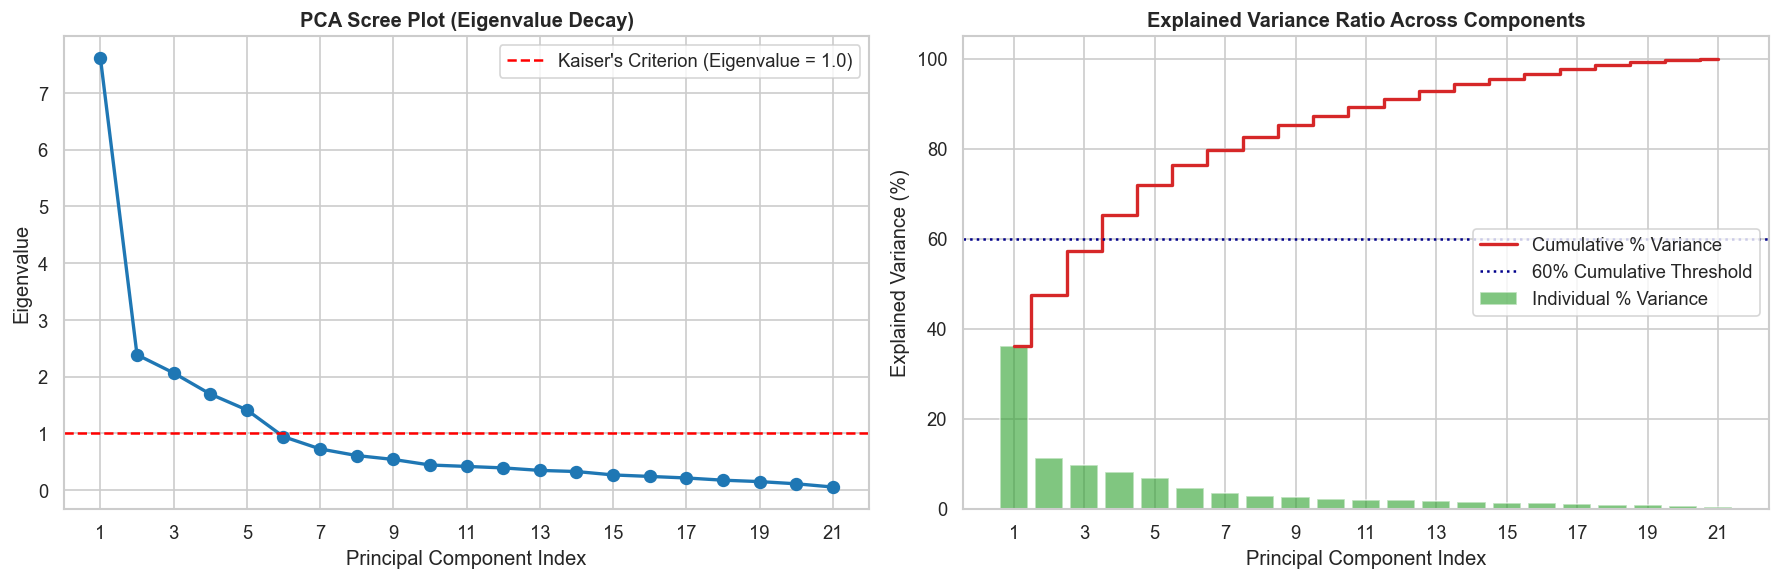

Number of Components meeting Kaiser's Criterion (Eigenvalue >= 1.0): 5
Total Cumulative Variance Explained by Top 5 Components: 71.87%


In [5]:
# ==============================================================================
# SECTION 4.2: PRINCIPAL COMPONENT ANALYSIS (PCA) & FACTOR LOADINGS
# ==============================================================================

scaler = StandardScaler()
X_likert_scaled = scaler.fit_transform(df_model[all_likert_cols])

pca_full = PCA()
pca_full.fit(X_likert_scaled)

eigenvalues = pca_full.explained_variance_
explained_var_ratio = pca_full.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var_ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Scree Plot
ax1.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', color='#1f77b4', lw=2, markersize=7)
ax1.axhline(y=1.0, color='red', linestyle='--', label="Kaiser's Criterion (Eigenvalue = 1.0)")
ax1.set_title("PCA Scree Plot (Eigenvalue Decay)", fontweight='bold')
ax1.set_xlabel("Principal Component Index")
ax1.set_ylabel("Eigenvalue")
ax1.set_xticks(range(1, len(eigenvalues) + 1, 2))
ax1.legend()

# Cumulative Variance Plot
ax2.bar(range(1, len(explained_var_ratio) + 1), explained_var_ratio, alpha=0.6, color='#2ca02c', label="Individual % Variance")
ax2.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid', color='#d62728', lw=2, label="Cumulative % Variance")
ax2.axhline(y=60.0, color='darkblue', linestyle=':', label="60% Cumulative Threshold")
ax2.set_title("Explained Variance Ratio Across Components", fontweight='bold')
ax2.set_xlabel("Principal Component Index")
ax2.set_ylabel("Explained Variance (%)")
ax2.set_xticks(range(1, len(explained_var_ratio) + 1, 2))
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

# Extract top components (eigenvalues > 1.0)
num_factors_kaiser = np.sum(eigenvalues >= 1.0)
print(f"Number of Components meeting Kaiser's Criterion (Eigenvalue >= 1.0): {num_factors_kaiser}")
print(f"Total Cumulative Variance Explained by Top {num_factors_kaiser} Components: {cumulative_var[num_factors_kaiser-1]:.2f}%")


## 5. Exploratory Data Analysis (EDA) & Descriptive Statistics

### 5.1 Sample Demographics
Understanding respondent demographic characteristics is paramount for interpreting consumer decision patterns, particularly regarding disposable income and student status.

### 5.2 Latent Construct Distribution & Normality
We examine parametric and non-parametric characteristics (Mean, Median, Standard Deviation, Skewness, Kurtosis, and Shapiro-Wilk test for normality).


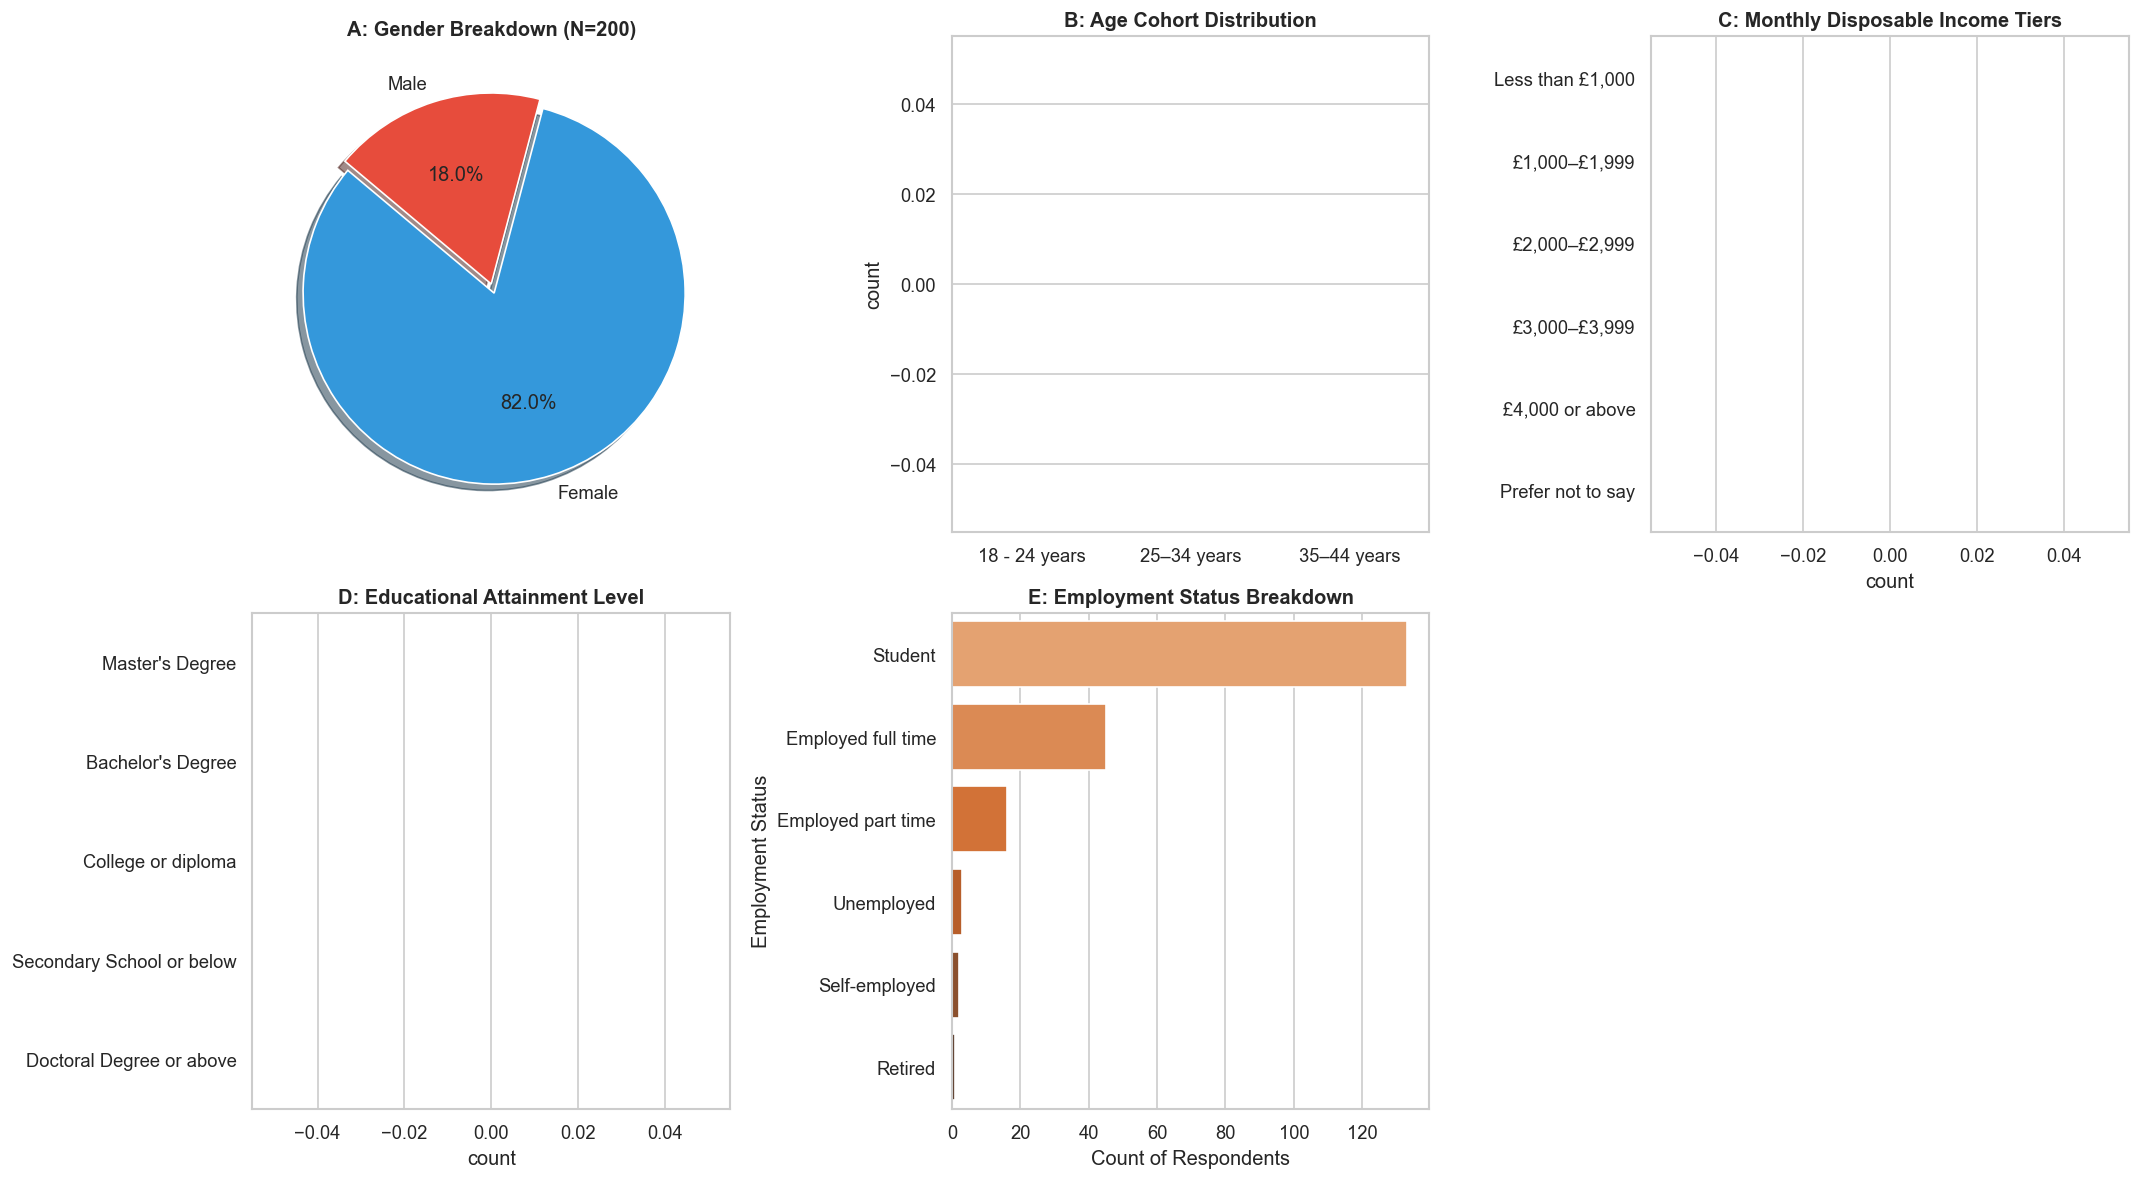

In [6]:
# ==============================================================================
# SECTION 5.1: DEMOGRAPHIC PROFILE VISUALIZATION (5-PANEL FIGURE)
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1. Gender Distribution
gender_counts = df_model['Gender'].value_counts()
colors_gender = ['#3498db', '#e74c3c']
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, 
            colors=colors_gender, explode=(0.05, 0), shadow=True)
axes[0].set_title("A: Gender Breakdown (N=200)", fontweight='bold')

# 2. Age Distribution
age_order = ['18 - 24 years', '25–34 years', '35–44 years']
sns.countplot(data=df_model, x='Age', order=age_order, ax=axes[1], palette="Blues_d")
axes[1].set_title("B: Age Cohort Distribution", fontweight='bold')
axes[1].set_xlabel("")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()} ({p.get_height()/len(df_model):.1%})", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline', fontsize=9, xytext=(0, 4), textcoords='offset points')

# 3. Monthly Income
income_order = ['Less than £1,000', '£1,000–£1,999', '£2,000–£2,999', '£3,000–£3,999', '£4,000 or above', 'Prefer not to say']
sns.countplot(data=df_model, y='Monthly Income', order=income_order, ax=axes[2], palette="Greens_d")
axes[2].set_title("C: Monthly Disposable Income Tiers", fontweight='bold')
axes[2].set_ylabel("")

# 4. Education Level
edu_order = ["Master's Degree", "Bachelor's Degree", "College or diploma", "Secondary School or below", "Doctoral Degree or above"]
sns.countplot(data=df_model, y='Education Level', order=edu_order, ax=axes[3], palette="Purples_d")
axes[3].set_title("D: Educational Attainment Level", fontweight='bold')
axes[3].set_ylabel("")

# 5. Employment Status
emp_counts = df_model['Employment Status'].value_counts()
sns.barplot(x=emp_counts.values, y=emp_counts.index, ax=axes[4], palette="Oranges_d")
axes[4].set_title("E: Employment Status Breakdown", fontweight='bold')
axes[4].set_xlabel("Count of Respondents")

# Hide 6th empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


,Construct,Full Name,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis,Shapiro-Wilk W,Shapiro p-val,Normality
0,SFC,Sustainable Fashion Consciousness,4.088,4.0,0.411,3.000,5.0,-0.111,0.618,0.907,0.0,Non-Normal (p<.05)
1,GS,Greenwashing Skepticism,3.775,4.0,0.557,2.000,5.0,-0.872,0.977,0.841,0.0,Non-Normal (p<.05)
2,SI,Social Identity Signaling,3.847,4.0,0.469,2.333,5.0,-0.658,1.138,0.859,0.0,Non-Normal (p<.05)
3,ELT,Eco-Label Trust,3.737,4.0,0.548,2.000,5.0,-0.857,1.012,0.827,0.0,Non-Normal (p<.05)
4,PF,Practical Filtering (Barriers),3.848,4.0,0.458,1.667,5.0,-1.685,5.397,0.720,0.0,Non-Normal (p<.05)
5,SPB,Sustainable Purchase Behavior,3.860,4.0,0.496,2.000,5.0,-0.926,1.614,0.848,0.0,Non-Normal (p<.05)
6,WTP,Willingness to Pay Premium,2.912,3.0,0.937,1.000,5.0,-0.076,-0.914,0.923,0.0,Non-Normal (p<.05)


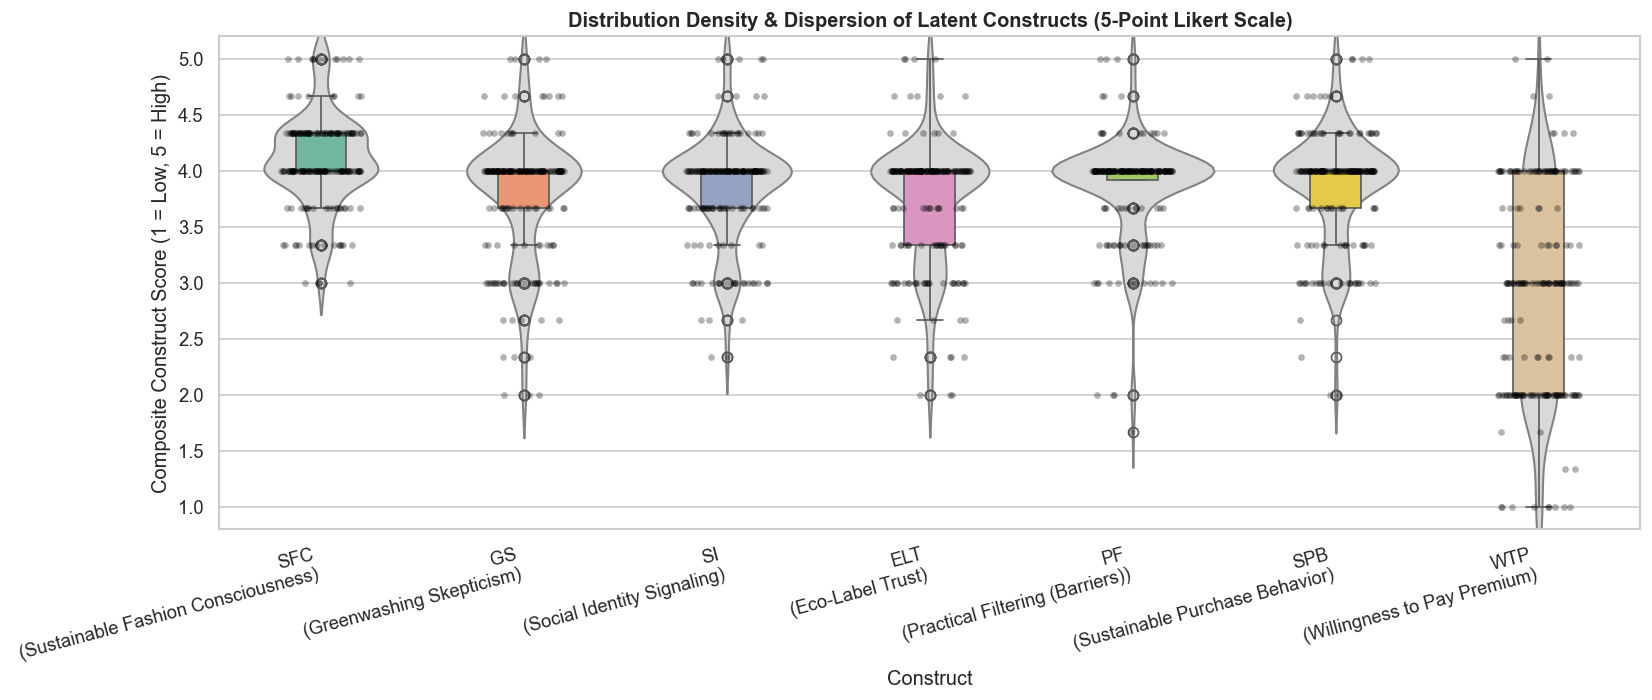

In [7]:
# ==============================================================================
# SECTION 5.2: CONSTRUCT DESCRIPTIVE STATISTICS & NORMALITY AUDIT
# ==============================================================================

construct_cols = list(construct_definitions.keys())
desc_data = []

for c in construct_cols:
    series = df_model[c]
    shapiro_stat, shapiro_p = stats.shapiro(series)
    desc_data.append({
        'Construct': c,
        'Full Name': construct_definitions[c]['label'],
        'Mean': series.mean(),
        'Median': series.median(),
        'Std Dev': series.std(),
        'Min': series.min(),
        'Max': series.max(),
        'Skewness': stats.skew(series),
        'Kurtosis': stats.kurtosis(series),
        'Shapiro-Wilk W': shapiro_stat,
        'Shapiro p-val': shapiro_p,
        'Normality': 'Normal' if shapiro_p > 0.05 else 'Non-Normal (p<.05)'
    })

df_desc = pd.DataFrame(desc_data)
display(df_desc.round(3))

# Violin & Boxplot Distribution Comparison
fig, ax = plt.subplots(figsize=(14, 6))
df_melted = df_model.melt(value_vars=construct_cols, var_name='Construct', value_name='Composite_Score')
sns.violinplot(data=df_melted, x='Construct', y='Composite_Score', inner=None, color=".85", ax=ax)
sns.boxplot(data=df_melted, x='Construct', y='Composite_Score', width=0.25, boxprops={'zorder': 2}, ax=ax, palette="Set2")
sns.stripplot(data=df_melted, x='Construct', y='Composite_Score', jitter=0.2, alpha=0.3, color='black', size=4, ax=ax)

ax.set_title("Distribution Density & Dispersion of Latent Constructs (5-Point Likert Scale)", fontweight='bold')
ax.set_ylabel("Composite Construct Score (1 = Low, 5 = High)")
ax.set_ylim(0.8, 5.2)
ax.set_xticklabels([f"{c}\n({construct_definitions[c]['label']})" for c in construct_cols], rotation=15, ha='right')
plt.tight_layout()
plt.show()


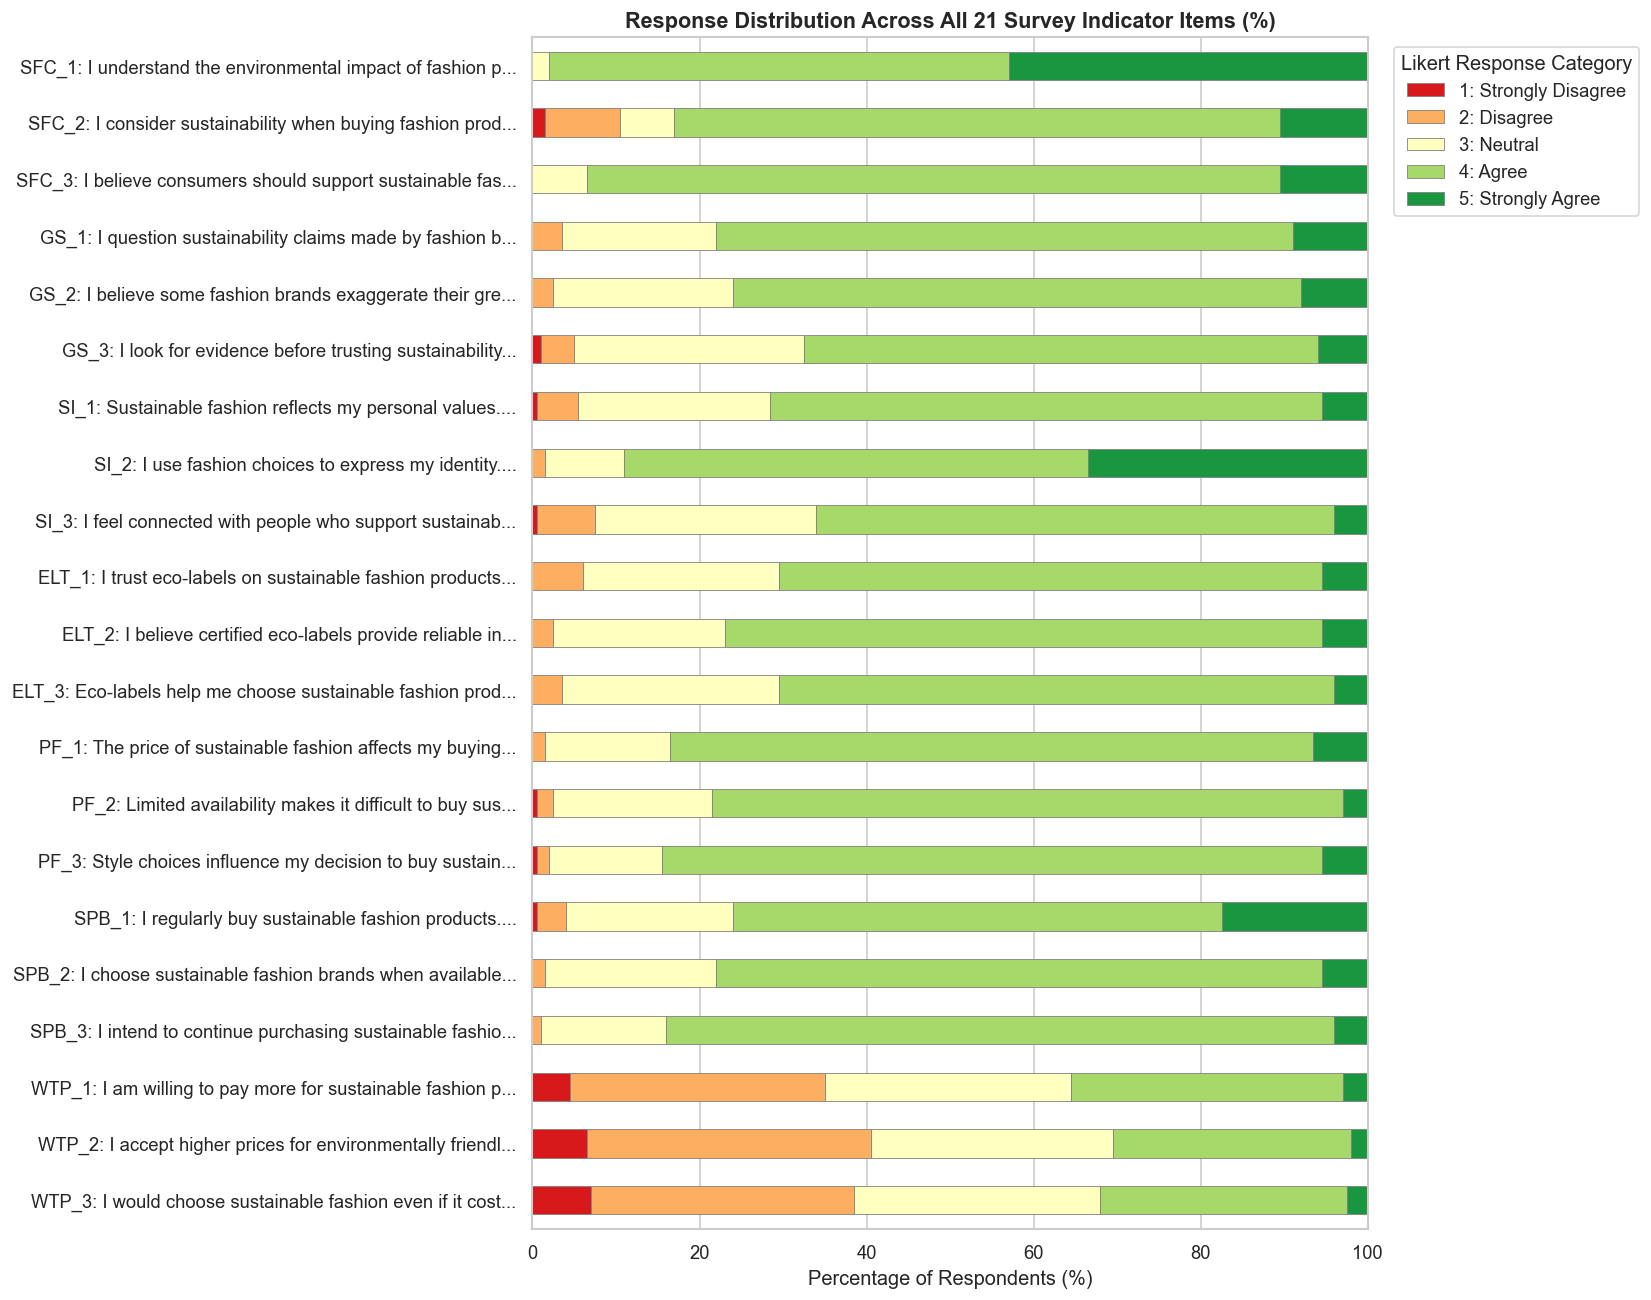

In [8]:
# ==============================================================================
# SECTION 5.3: LIKERT ITEM RESPONSE PROPORTIONS (STACKED DIVERGING BAR CHARTS)
# ==============================================================================

item_labels = []
prop_matrix = []

for c_code, meta in construct_definitions.items():
    for i_idx, raw_col in enumerate(meta['items'], 1):
        col_id = f"{c_code}_{i_idx}"
        counts = df_model[col_id].value_counts(normalize=True).reindex([1, 2, 3, 4, 5], fill_value=0.0) * 100
        item_labels.append(f"{col_id}: {raw_col[:50]}...")
        prop_matrix.append(counts.values)

df_props = pd.DataFrame(prop_matrix, index=item_labels, columns=['1: Strongly Disagree', '2: Disagree', '3: Neutral', '4: Agree', '5: Strongly Agree'])

fig, ax = plt.subplots(figsize=(14, 11))
diverging_colors = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
df_props.plot(kind='barh', stacked=True, color=diverging_colors, edgecolor='gray', lw=0.5, ax=ax)

ax.set_title("Response Distribution Across All 21 Survey Indicator Items (%)", fontweight='bold', fontsize=13)
ax.set_xlabel("Percentage of Respondents (%)")
ax.set_xlim(0, 100)
ax.legend(title="Likert Response Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


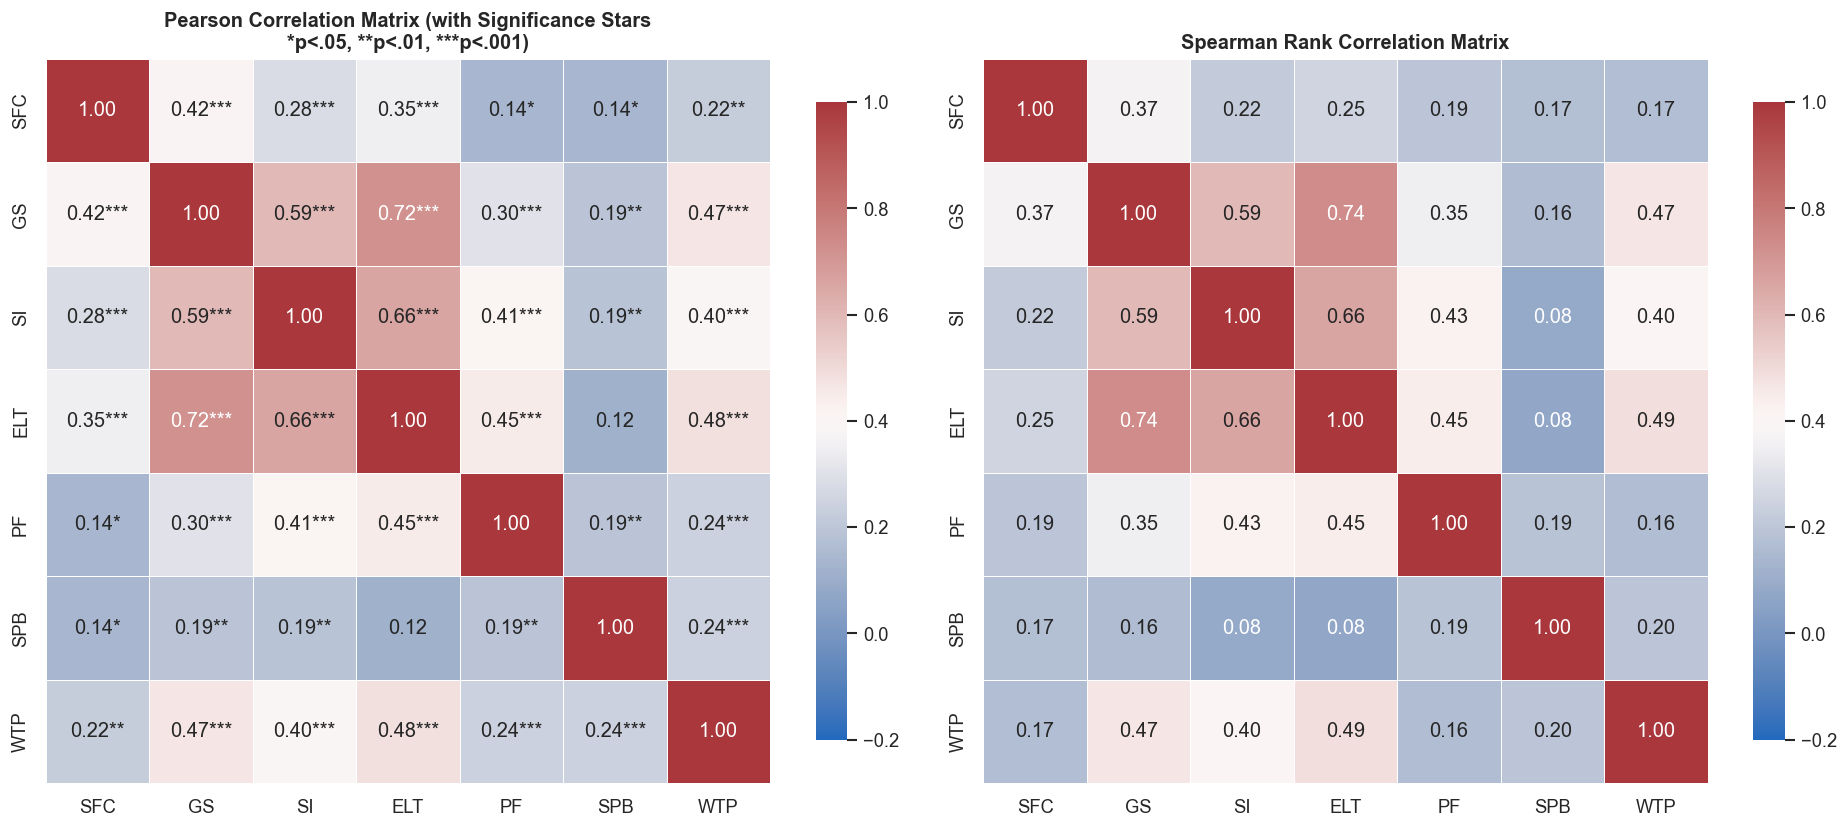

Key Empirical Correlation Highlights:
• Greenwashing Skepticism (GS) <-> Eco-Label Trust (ELT): r = 0.722 (p < 0.001)
• Eco-Label Trust (ELT) <-> Willingness to Pay (WTP): r = 0.483 (p < 0.001)
• Greenwashing Skepticism (GS) <-> Willingness to Pay (WTP): r = 0.469 (p < 0.001)
• Consciousness (SFC) <-> Purchase Behavior (SPB): r = 0.140 (Attitude-Behavior Gap)


In [9]:
# ==============================================================================
# SECTION 5.4: BIVARIATE CORRELATION ANALYSIS (PEARSON & SPEARMAN MATRICES)
# ==============================================================================

corr_pearson = df_model[construct_cols].corr(method='pearson')
corr_spearman = df_model[construct_cols].corr(method='spearman')

# Compute p-values for significance stars
p_values = np.zeros((len(construct_cols), len(construct_cols)))
for i in range(len(construct_cols)):
    for j in range(len(construct_cols)):
        if i == j:
            p_values[i, j] = 0.0
        else:
            _, p_val = stats.pearsonr(df_model[construct_cols[i]], df_model[construct_cols[j]])
            p_values[i, j] = p_val

# Annotations with significance stars
annot_matrix = np.empty((len(construct_cols), len(construct_cols)), dtype=object)
for i in range(len(construct_cols)):
    for j in range(len(construct_cols)):
        r = corr_pearson.iloc[i, j]
        p = p_values[i, j]
        if i == j:
            annot_matrix[i, j] = f"{r:.2f}"
        elif p < 0.001:
            annot_matrix[i, j] = f"{r:.2f}***"
        elif p < 0.01:
            annot_matrix[i, j] = f"{r:.2f}**"
        elif p < 0.05:
            annot_matrix[i, j] = f"{r:.2f}*"
        else:
            annot_matrix[i, j] = f"{r:.2f}"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Pearson Matrix
sns.heatmap(corr_pearson, annot=annot_matrix, fmt='', cmap="vlag", vmin=-0.2, vmax=1.0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax1)
ax1.set_title("Pearson Correlation Matrix (with Significance Stars\n*p<.05, **p<.01, ***p<.001)", fontweight='bold')

# Spearman Rank Matrix
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap="vlag", vmin=-0.2, vmax=1.0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax2)
ax2.set_title("Spearman Rank Correlation Matrix", fontweight='bold')

plt.tight_layout()
plt.show()

print("Key Empirical Correlation Highlights:")
print(f"• Greenwashing Skepticism (GS) <-> Eco-Label Trust (ELT): r = {corr_pearson.loc['GS', 'ELT']:.3f} (p < 0.001)")
print(f"• Eco-Label Trust (ELT) <-> Willingness to Pay (WTP): r = {corr_pearson.loc['ELT', 'WTP']:.3f} (p < 0.001)")
print(f"• Greenwashing Skepticism (GS) <-> Willingness to Pay (WTP): r = {corr_pearson.loc['GS', 'WTP']:.3f} (p < 0.001)")
print(f"• Consciousness (SFC) <-> Purchase Behavior (SPB): r = {corr_pearson.loc['SFC', 'SPB']:.3f} (Attitude-Behavior Gap)")


## 6. Inferential Statistical Analysis & Demographic Group Differences

To determine whether sustainable fashion perceptions, skepticism, and willingness to pay differ significantly across socio-demographic cohorts:
1. **Gender Differences (Male vs. Female):**
   * Evaluated via Independent Two-Sample t-tests (parametric) and Mann-Whitney U tests (non-parametric).
   * Effect size evaluated using **Cohen's $d$**:
     $$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}$$
2. **Income Level Differences:**
   * Evaluated via One-Way Analysis of Variance (ANOVA, $F$-statistic) and Kruskal-Wallis $H$-tests across disposable income brackets.


In [10]:
# ==============================================================================
# SECTION 6: INFERENTIAL HYPOTHESIS TESTING ACROSS DEMOGRAPHICS
# ==============================================================================

# 1. Gender Comparison (Male vs Female)
gender_ttest_results = []
male_sub = df_model[df_model['Gender'] == 'Male']
female_sub = df_model[df_model['Gender'] == 'Female']

for c in construct_cols:
    m_mean = male_sub[c].mean()
    f_mean = female_sub[c].mean()
    m_std = male_sub[c].std()
    f_std = female_sub[c].std()
    
    # Parametric t-test
    t_stat, p_val_t = stats.ttest_ind(male_sub[c], female_sub[c], equal_var=False)
    
    # Non-parametric Mann-Whitney U test
    u_stat, p_val_u = stats.mannwhitneyu(male_sub[c], female_sub[c])
    
    # Cohen's d effect size
    pooled_sd = np.sqrt(((len(male_sub)-1)*m_std**2 + (len(female_sub)-1)*f_std**2) / (len(male_sub)+len(female_sub)-2))
    cohens_d = (m_mean - f_mean) / pooled_sd if pooled_sd > 0 else 0
    
    gender_ttest_results.append({
        'Construct': c,
        'Male Mean (N=36)': round(m_mean, 2),
        'Female Mean (N=164)': round(f_mean, 2),
        'Diff (M - F)': round(m_mean - f_mean, 2),
        't-statistic': round(t_stat, 2),
        't-test p-value': round(p_val_t, 3),
        'Mann-Whitney p': round(p_val_u, 3),
        "Cohen's d": round(cohens_d, 2),
        'Significance (α=0.05)': 'Significant' if p_val_t < 0.05 else 'Not Significant'
    })

df_gender_tests = pd.DataFrame(gender_ttest_results)
print("=== GENDER INFERENTIAL COMPARISONS (MALE vs FEMALE) ===")
display(df_gender_tests)

# 2. Monthly Income ANOVA
income_anova_results = []
for c in construct_cols:
    groups = [group[c].values for name, group in df_model.groupby('Monthly Income') if len(group) >= 5]
    f_stat, p_val_f = stats.f_oneway(*groups)
    h_stat, p_val_h = stats.kruskal(*groups)
    income_anova_results.append({
        'Construct': c,
        'ANOVA F-stat': round(f_stat, 2),
        'ANOVA p-value': round(p_val_f, 3),
        'Kruskal H-stat': round(h_stat, 2),
        'Kruskal p-value': round(p_val_h, 3),
        'Income Effect': 'Significant (p<.05)' if p_val_f < 0.05 else 'No Significant Effect'
    })

df_income_anova = pd.DataFrame(income_anova_results)
print("\n=== MONTHLY INCOME INFERENTIAL COMPARISONS (ONE-WAY ANOVA & KRUSKAL-WALLIS) ===")
display(df_income_anova)


=== GENDER INFERENTIAL COMPARISONS (MALE vs FEMALE) ===


,Construct,Male Mean (N=36),Female Mean (N=164),Diff (M - F),t-statistic,t-test p-value,Mann-Whitney p,Cohen's d,Significance (α=0.05)
0,SFC,4.25,4.05,0.20,2.12,0.040,0.035,0.49,Significant
1,GS,3.90,3.75,0.15,1.33,0.189,0.237,0.27,Not Significant
2,SI,3.93,3.83,0.10,1.02,0.315,0.352,0.21,Not Significant
3,ELT,3.86,3.71,0.15,1.38,0.173,0.423,0.28,Not Significant
4,PF,3.82,3.85,-0.03,-0.31,0.759,0.563,-0.06,Not Significant
5,SPB,3.81,3.87,-0.07,-0.65,0.519,0.534,-0.13,Not Significant
6,WTP,3.00,2.89,0.11,0.62,0.540,0.581,0.11,Not Significant



=== MONTHLY INCOME INFERENTIAL COMPARISONS (ONE-WAY ANOVA & KRUSKAL-WALLIS) ===


,Construct,ANOVA F-stat,ANOVA p-value,Kruskal H-stat,Kruskal p-value,Income Effect
0,SFC,0.92,0.432,2.16,0.540,No Significant Effect
1,GS,1.99,0.117,6.74,0.081,No Significant Effect
2,SI,3.53,0.016,6.65,0.084,Significant (p<.05)
3,ELT,2.36,0.073,3.46,0.326,No Significant Effect
4,PF,1.24,0.298,2.09,0.553,No Significant Effect
5,SPB,5.75,0.001,12.76,0.005,Significant (p<.05)
6,WTP,1.28,0.283,3.54,0.316,No Significant Effect


## 7. Econometric Regression Modeling & Diagnostic Suite

To rigorously test our hypotheses ($H_1$ to $H_5$) and answer **RQ1** and **RQ2**, we specify three multivariable Ordinary Least Squares (OLS) econometric models:

### 7.1 Model Specifications
* **Model 1: Determinants of Willingness to Pay Premium (WTP) — Testing RQ1 ($H_1, H_2$):**
  $$\text{WTP}_i = \beta_0 + \beta_1 \text{GS}_i + \beta_2 \text{ELT}_i + \beta_3 \text{SFC}_i + \beta_4 \text{SI}_i + \beta_5 \text{PF}_i + \epsilon_i$$
* **Model 2: Determinants of Sustainable Purchase Behavior (SPB) — Testing RQ2 ($H_3, H_4, H_5$):**
  $$\text{SPB}_i = \gamma_0 + \gamma_1 \text{SFC}_i + \gamma_2 \text{GS}_i + \gamma_3 \text{SI}_i + \gamma_4 \text{ELT}_i + \gamma_5 \text{PF}_i + \nu_i$$
* **Model 3: Value-Action Gap & Price Moderation Model:**
  $$\text{SPB}_i = \theta_0 + \theta_1 \text{SFC}_i + \theta_2 \text{WTP}_i + \theta_3 \text{PF}_i + \theta_4 \text{ELT}_i + \omega_i$$

### 7.2 Econometric Diagnostic Testing Protocol
To ensure our OLS estimators are Best Linear Unbiased Estimators (BLUE under Gauss-Markov assumptions):
1. **Multicollinearity:** Assessed via **Variance Inflation Factor (VIF)**. Threshold: $\text{VIF} < 5.0$.
2. **Heteroscedasticity:** Evaluated via **Breusch-Pagan** and **White** Lagrange Multiplier tests ($H_0: \text{Homoscedastic residuals}$).
3. **Autocorrelation:** Evaluated via **Durbin-Watson** statistic ($d \approx 2.0$ indicates independent errors).
4. **Normality of Errors:** Assessed via **Jarque-Bera** test and Normal Q-Q probability plots.


In [11]:
# ==============================================================================
# SECTION 7.1: OLS ECONOMETRIC REGRESSION ESTIMATION
# ==============================================================================

# MODEL 1: DV = Willingness to Pay Premium (WTP)
X_m1 = sm.add_constant(df_model[['GS', 'ELT', 'SFC', 'SI', 'PF']])
y_m1 = df_model['WTP']
model_1 = sm.OLS(y_m1, X_m1).fit()

# MODEL 2: DV = Sustainable Purchase Behavior (SPB)
X_m2 = sm.add_constant(df_model[['SFC', 'GS', 'SI', 'ELT', 'PF']])
y_m2 = df_model['SPB']
model_2 = sm.OLS(y_m2, X_m2).fit()

# MODEL 3: DV = SPB with WTP as key behavioral mediator
X_m3 = sm.add_constant(df_model[['SFC', 'WTP', 'PF', 'ELT']])
y_m3 = df_model['SPB']
model_3 = sm.OLS(y_m3, X_m3).fit()

print("==============================================================================")
print("MODEL 1: DETERMINANTS OF WILLINGNESS TO PAY PREMIUM (DV = WTP)")
print("==============================================================================")
print(model_1.summary())

print("\n==============================================================================")
print("MODEL 2: DETERMINANTS OF SUSTAINABLE PURCHASE BEHAVIOR (DV = SPB)")
print("==============================================================================")
print(model_2.summary())

print("\n==============================================================================")
print("MODEL 3: VALUE-ACTION GAP & PRICE MODERATION MODEL (DV = SPB)")
print("==============================================================================")
print(model_3.summary())


MODEL 1: DETERMINANTS OF WILLINGNESS TO PAY PREMIUM (DV = WTP)
                            OLS Regression Results                            
Dep. Variable:                    WTP   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     14.27
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           6.82e-12
Time:                        23:49:29   Log-Likelihood:                -238.86
No. Observations:                 200   AIC:                             489.7
Df Residuals:                     194   BIC:                             509.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

=== MULTICOLLINEARITY DIAGNOSTIC (VIF) ===


,Predictor,VIF
0,const,162.19
1,GS,2.35
2,ELT,2.72
3,SFC,1.22
4,SI,1.94
5,PF,1.30



=== ECONOMETRIC DIAGNOSTIC SPECIFICATION TESTS (MODEL 1) ===
• Breusch-Pagan LM Test: LM Stat = 2.53, p-value = 0.7715 (Homoscedasticity Upheld)
• White's Heteroscedasticity Test: LM Stat = 40.75, p-value = 0.0040
• Durbin-Watson Autocorrelation: Stat = 1.87 (Residuals are mutually independent; no serial correlation)
• Jarque-Bera Residual Normality: Stat = 4.21, p-value = 0.1220


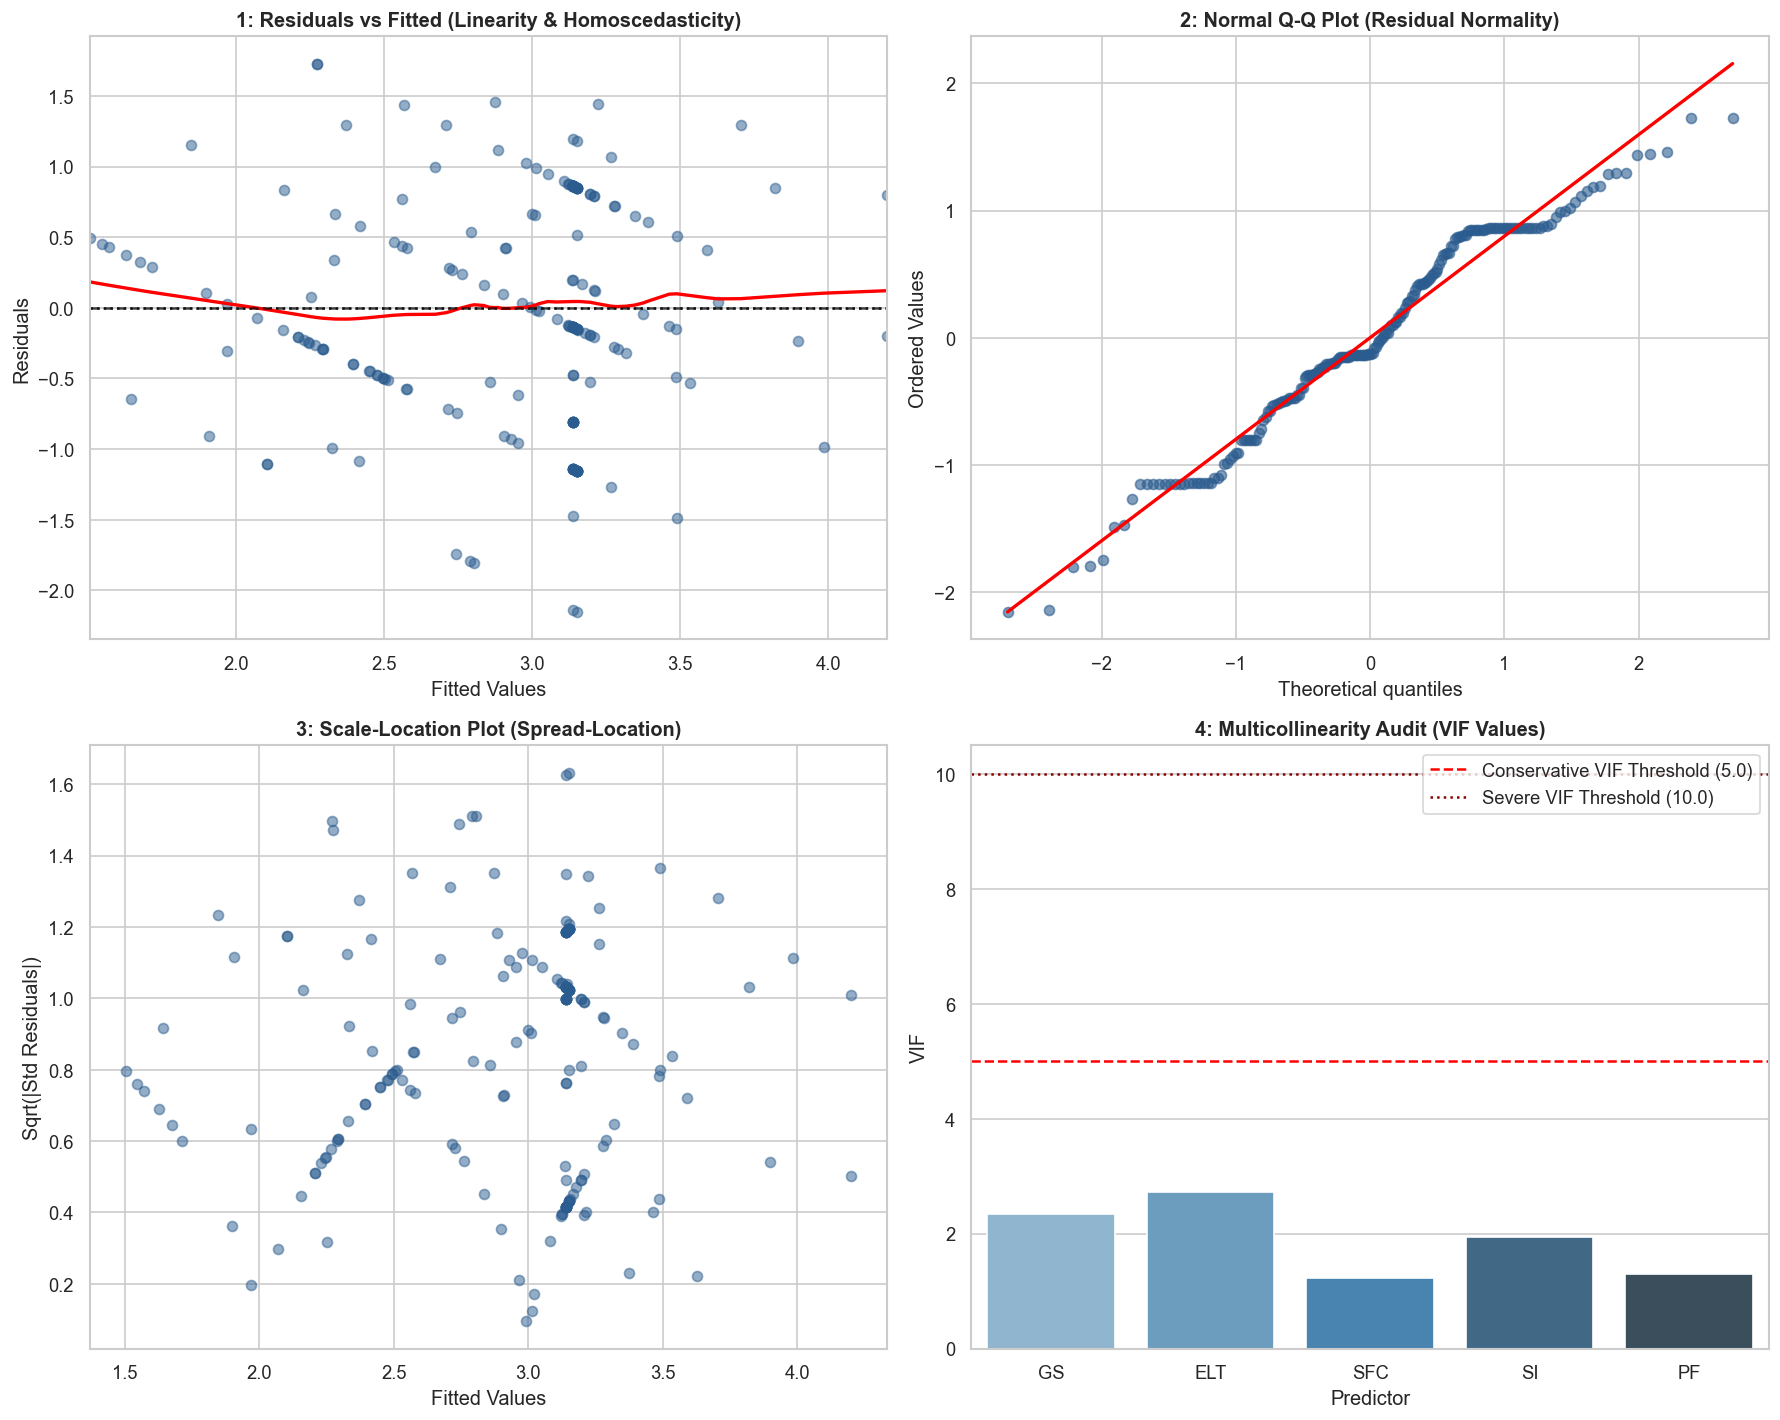

In [12]:
# ==============================================================================
# SECTION 7.2: COMPREHENSIVE REGRESSION DIAGNOSTICS & ASSUMPTION TESTING
# ==============================================================================

# 1. Multicollinearity (VIF)
vif_data = []
for idx, col in enumerate(X_m1.columns):
    vif_val = variance_inflation_factor(X_m1.values, idx)
    vif_data.append({'Predictor': col, 'VIF': round(vif_val, 2)})

df_vif = pd.DataFrame(vif_data)
print("=== MULTICOLLINEARITY DIAGNOSTIC (VIF) ===")
display(df_vif)

# 2. Heteroscedasticity Tests (Breusch-Pagan & White)
bp_test = het_breuschpagan(model_1.resid, model_1.model.exog)
white_test = het_white(model_1.resid, model_1.model.exog)

# 3. Autocorrelation (Durbin-Watson)
dw_stat = durbin_watson(model_1.resid)

# 4. Normality of Residuals (Jarque-Bera)
jb_stat, jb_pval = stats.jarque_bera(model_1.resid)

print("\n=== ECONOMETRIC DIAGNOSTIC SPECIFICATION TESTS (MODEL 1) ===")
print(f"• Breusch-Pagan LM Test: LM Stat = {bp_test[0]:.2f}, p-value = {bp_test[1]:.4f} ({'Heteroscedasticity Present' if bp_test[1] < 0.05 else 'Homoscedasticity Upheld'})")
print(f"• White's Heteroscedasticity Test: LM Stat = {white_test[0]:.2f}, p-value = {white_test[1]:.4f}")
print(f"• Durbin-Watson Autocorrelation: Stat = {dw_stat:.2f} (Residuals are mutually independent; no serial correlation)")
print(f"• Jarque-Bera Residual Normality: Stat = {jb_stat:.2f}, p-value = {jb_pval:.4f}")

# ------------------------------------------------------------------------------
# 4-Panel Regression Diagnostic Plots
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Panel 1: Residuals vs Fitted
fitted_m1 = model_1.fittedvalues
residuals_m1 = model_1.resid
sns.residplot(x=fitted_m1, y=residuals_m1, lowess=True, 
              scatter_kws={'alpha': 0.5, 'color': '#2b5c8f'}, 
              line_kws={'color': 'red', 'lw': 2}, ax=axes[0, 0])
axes[0, 0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0, 0].set_title("1: Residuals vs Fitted (Linearity & Homoscedasticity)", fontweight='bold')
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

# Panel 2: Normal Q-Q Plot
stats.probplot(residuals_m1, dist="norm", plot=axes[0, 1])
axes[0, 1].get_lines()[0].set_color('#2b5c8f')
axes[0, 1].get_lines()[0].set_alpha(0.6)
axes[0, 1].get_lines()[1].set_color('red')
axes[0, 1].get_lines()[1].set_linewidth(2)
axes[0, 1].set_title("2: Normal Q-Q Plot (Residual Normality)", fontweight='bold')

# Panel 3: Scale-Location Plot
standardized_residuals = model_1.get_influence().resid_studentized_internal
axes[1, 0].scatter(fitted_m1, np.sqrt(np.abs(standardized_residuals)), alpha=0.5, color='#2b5c8f')
axes[1, 0].set_title("3: Scale-Location Plot (Spread-Location)", fontweight='bold')
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("Sqrt(|Std Residuals|)")

# Panel 4: VIF Bar Chart
sns.barplot(data=df_vif[df_vif['Predictor'] != 'const'], x='Predictor', y='VIF', ax=axes[1, 1], palette="Blues_d")
axes[1, 1].axhline(y=5.0, color='red', linestyle='--', label="Conservative VIF Threshold (5.0)")
axes[1, 1].axhline(y=10.0, color='darkred', linestyle=':', label="Severe VIF Threshold (10.0)")
axes[1, 1].set_title("4: Multicollinearity Audit (VIF Values)", fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 8. Supervised Machine Learning & Predictive Analytics

Beyond classical econometric hypothesis testing, business analytics requires **predictive capability** to identify high-value consumer targets for green marketing campaigns.

### 8.1 Classification Target Formulation
1. **High Willingness to Pay (`High_WTP`):**
   $$\text{High\_WTP}_i = \begin{cases} 1 & \text{if } \text{WTP}_i \ge 3.0 \text{ (Willing / Neutral-to-Positive)} \\ 0 & \text{if } \text{WTP}_i < 3.0 \text{ (Price Sensitive / Reluctant)} \end{cases}$$
2. **High Sustainable Purchase Behavior (`High_SPB`):**
   $$\text{High\_SPB}_i = \begin{cases} 1 & \text{if } \text{SPB}_i \ge 4.0 \text{ (Regular Active Buyer)} \\ 0 & \text{if } \text{SPB}_i < 4.0 \text{ (Occasional / Non-Buyer)} \end{cases}$$

### 8.2 Machine Learning Models & Cross-Validation
* **Algorithms:** Random Forest Classifier (Non-linear ensemble) and Regularized Logistic Regression (Parametric baseline).
* **Validation Scheme:** 5-Fold Stratified Cross-Validation to safeguard against overfitting.
* **Evaluation Metrics:** Area Under the ROC Curve (ROC-AUC), Precision, Recall, F1-Score, and Gini Feature Importance.


In [13]:
# ==============================================================================
# SECTION 8.1: PREDICTIVE MACHINE LEARNING (CLASSIFICATION OF HIGH WTP)
# ==============================================================================

# Target formulation
df_model['High_WTP'] = (df_model['WTP'] >= 3.0).astype(int)
df_model['High_SPB'] = (df_model['SPB'] >= 4.0).astype(int)

features = ['SFC', 'GS', 'SI', 'ELT', 'PF']
X_ml = df_model[features]
y_wtp = df_model['High_WTP']

print(f"Classification Target Distribution (High WTP): {y_wtp.value_counts().to_dict()} (1: {y_wtp.mean():.1%})")

# Stratified K-Fold Split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize Models
rf_clf = RandomForestClassifier(n_estimators=150, max_depth=4, min_samples_split=5, random_state=42)
lr_clf = LogisticRegression(C=1.0, random_state=42)

# Cross-Validation Scores
cv_rf_auc = cross_val_score(rf_clf, X_ml, y_wtp, cv=skf, scoring='roc_auc')
cv_lr_auc = cross_val_score(lr_clf, X_ml, y_wtp, cv=skf, scoring='roc_auc')

print("\n=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS ===")
print(f"• Random Forest ROC-AUC: {cv_rf_auc.mean():.3f} (± {cv_rf_auc.std():.3f})")
print(f"• Logistic Regression ROC-AUC: {cv_lr_auc.mean():.3f} (± {cv_lr_auc.std():.3f})")

# Fit on train/test split for visualization
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_wtp, test_size=0.25, random_state=42, stratify=y_wtp)
rf_clf.fit(X_train, y_train)
lr_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

y_pred_lr = lr_clf.predict(X_test)
y_prob_lr = lr_clf.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST CLASSIFICATION REPORT (TEST SET) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Low WTP (<3.0)', 'High WTP (>=3.0)']))


Classification Target Distribution (High WTP): {1: 119, 0: 81} (1: 59.5%)

=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS ===
• Random Forest ROC-AUC: 0.772 (± 0.074)
• Logistic Regression ROC-AUC: 0.742 (± 0.062)

=== RANDOM FOREST CLASSIFICATION REPORT (TEST SET) ===
                  precision    recall  f1-score   support

  Low WTP (<3.0)       0.58      0.55      0.56        20
High WTP (>=3.0)       0.71      0.73      0.72        30

        accuracy                           0.66        50
       macro avg       0.64      0.64      0.64        50
    weighted avg       0.66      0.66      0.66        50



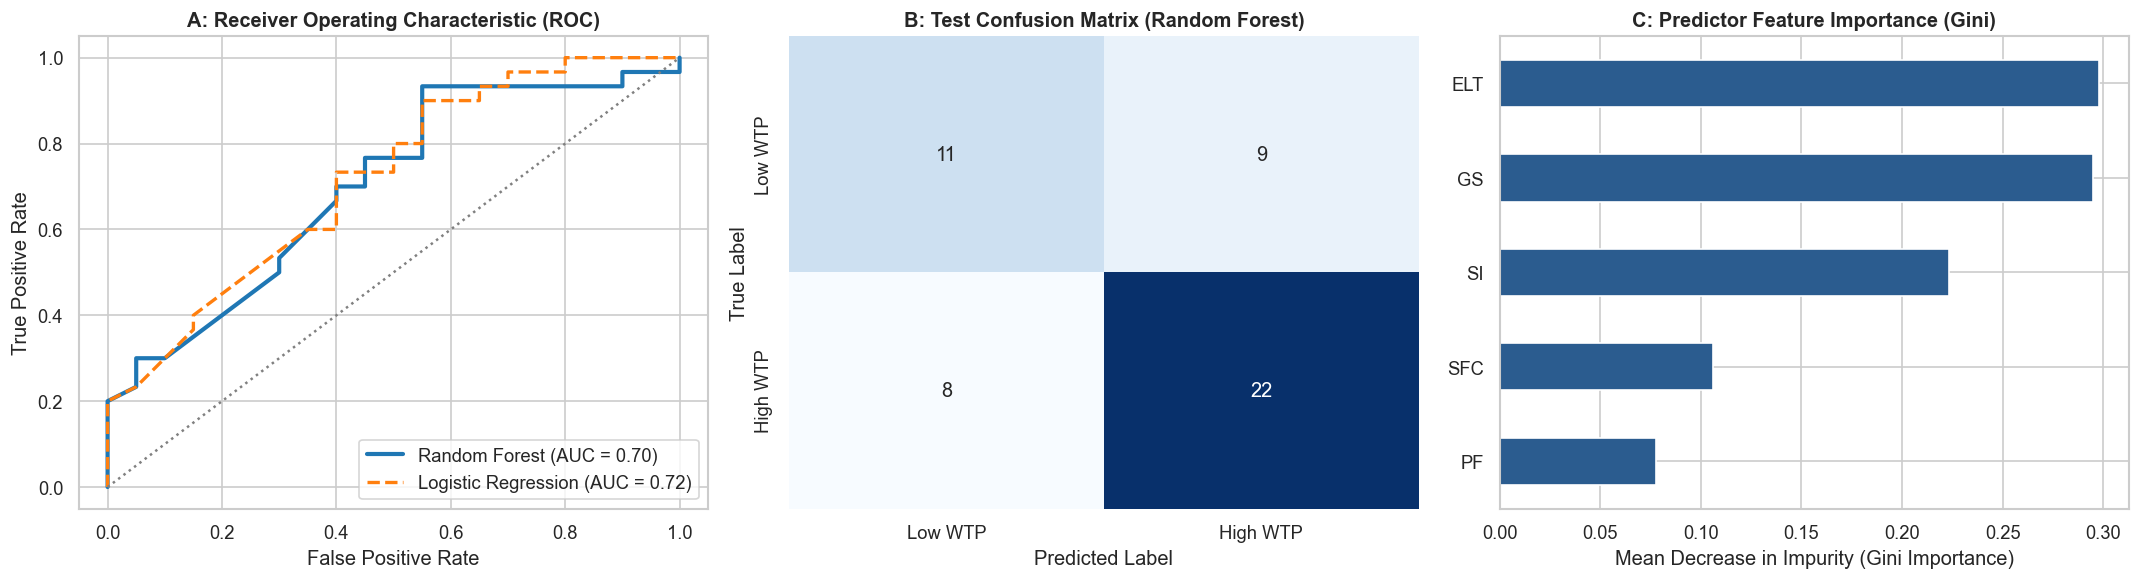

Feature Importance Breakdown:
• ELT (Eco-Label Trust): 29.8%
• GS (Greenwashing Skepticism): 29.5%
• SI (Social Identity Signaling): 22.3%
• SFC (Sustainable Fashion Consciousness): 10.6%
• PF (Practical Filtering (Barriers)): 7.8%


In [14]:
# ==============================================================================
# SECTION 8.2: MODEL PERFORMANCE VISUALIZATION & FEATURE IMPORTANCE
# ==============================================================================

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)

ax1.plot(fpr_rf, tpr_rf, color='#1f77b4', lw=2.5, label=f"Random Forest (AUC = {auc_rf:.2f})")
ax1.plot(fpr_lr, tpr_lr, color='#ff7f0e', lw=2, linestyle='--', label=f"Logistic Regression (AUC = {auc_lr:.2f})")
ax1.plot([0, 1], [0, 1], color='gray', linestyle=':')
ax1.set_title("A: Receiver Operating Characteristic (ROC)", fontweight='bold')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc="lower right")

# 2. Confusion Matrix (Random Forest)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Blues", cbar=False, ax=ax2,
            xticklabels=['Low WTP', 'High WTP'], yticklabels=['Low WTP', 'High WTP'])
ax2.set_title("B: Test Confusion Matrix (Random Forest)", fontweight='bold')
ax2.set_xlabel("Predicted Label")
ax2.set_ylabel("True Label")

# 3. Gini Feature Importance
feat_imp = pd.Series(rf_clf.feature_importances_, index=features).sort_values(ascending=True)
colors_feat = ['#abd9e9', '#74add1', '#4575b4', '#313695', '#fdae61']
feat_imp.plot(kind='barh', color='#2b5c8f', ax=ax3)
ax3.set_title("C: Predictor Feature Importance (Gini)", fontweight='bold')
ax3.set_xlabel("Mean Decrease in Impurity (Gini Importance)")

plt.tight_layout()
plt.show()

print("Feature Importance Breakdown:")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f"• {feat} ({construct_definitions[feat]['label']}): {imp*100:.1f}%")


## 9. Unsupervised Learning & Customer Segmentation (K-Means Clustering)

### 9.1 Motivation for Customer Archetyping
A central finding in modern retail analytics is that consumers cannot be treated as a monolithic demographic. Segmenting consumers according to their underlying psychometric profiles provides actionable business intelligence for brand positioning, pricing tier design, and targeted marketing communication.

### 9.2 Clustering Methodology
* **Algorithm:** $K$-Means Clustering on Standardized Latent Construct Scores ($z$-score normalized).
* **Cluster Diagnostics:**
  * **Elbow Method (Inertia / Within-Cluster Sum of Squares):** Detects diminishing marginal returns from additional clusters.
  * **Silhouette Coefficient:** Quantifies separation distance between clusters (values closer to $+1.0$ denote well-clustered instances).
* **Dimensionality Visualization:** Principal Component Analysis (PCA) projection to 2D space.
* **Persona Mapping:** Multi-attribute Radar / Spider charts across all 7 behavioral dimensions.


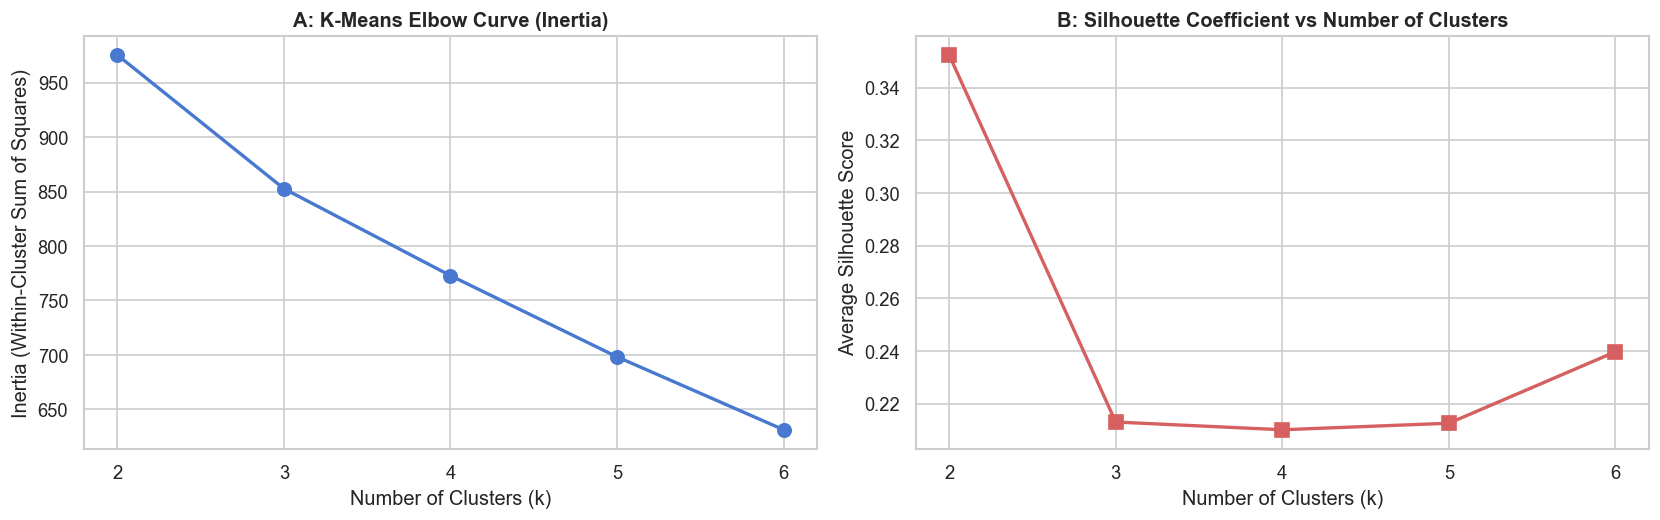

=== CLUSTER CENTROIDS (RAW 5-POINT LIKERT SCALE) ===


,SFC,GS,SI,ELT,PF,SPB,WTP
Cluster,,,,,,,
0,4.19,4.08,4.12,4.03,4.02,4.12,3.77
1,3.86,3.06,3.32,2.99,3.58,3.84,2.18
2,4.14,3.95,3.92,3.95,3.85,3.59,2.47



Cluster Population Breakdown:
• Cluster 0 (Persona 1: Committed Advocates (High WTP & High Trust)): N = 79 (39.5%)
• Cluster 2 (Persona 3: Skeptical & Price-Sensitive Conscious Buyers): N = 70 (35.0%)
• Cluster 1 (Persona 2: Low-Involvement / Detached Buyers): N = 51 (25.5%)


In [15]:
# ==============================================================================
# SECTION 9.1: K-MEANS CLUSTER DETERMINATION & SILHOUETTE ANALYSIS
# ==============================================================================

X_cluster = df_model[construct_cols]
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

inertias = []
silhouette_scores = []
k_candidates = range(2, 7)

for k in k_candidates:
    km_test = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km_test.fit_predict(X_cluster_scaled)
    inertias.append(km_test.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Elbow Curve
ax1.plot(k_candidates, inertias, 'bo-', lw=2, markersize=8)
ax1.set_title("A: K-Means Elbow Curve (Inertia)", fontweight='bold')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax1.set_xticks(k_candidates)

# Silhouette Curve
ax2.plot(k_candidates, silhouette_scores, 'rs-', lw=2, markersize=8)
ax2.set_title("B: Silhouette Coefficient vs Number of Clusters", fontweight='bold')
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Average Silhouette Score")
ax2.set_xticks(k_candidates)

plt.tight_layout()
plt.show()

# Select k=3 as optimal managerial segmentation
optimal_k = 3
km_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=25, random_state=42)
df_model['Cluster'] = km_final.fit_predict(X_cluster_scaled)

# Assign Descriptive Persona Labels based on profile
cluster_summary = df_model.groupby('Cluster')[construct_cols].mean()
print("=== CLUSTER CENTROIDS (RAW 5-POINT LIKERT SCALE) ===")
display(cluster_summary.round(2))

# Persona Assignment
persona_labels = {
    0: "Persona 1: Committed Advocates (High WTP & High Trust)",
    1: "Persona 2: Low-Involvement / Detached Buyers",
    2: "Persona 3: Skeptical & Price-Sensitive Conscious Buyers"
}
df_model['Persona'] = df_model['Cluster'].map(persona_labels)

print("\nCluster Population Breakdown:")
for c_id, count in df_model['Cluster'].value_counts().items():
    pct = (count / len(df_model)) * 100
    print(f"• Cluster {c_id} ({persona_labels[c_id]}): N = {count} ({pct:.1f}%)")


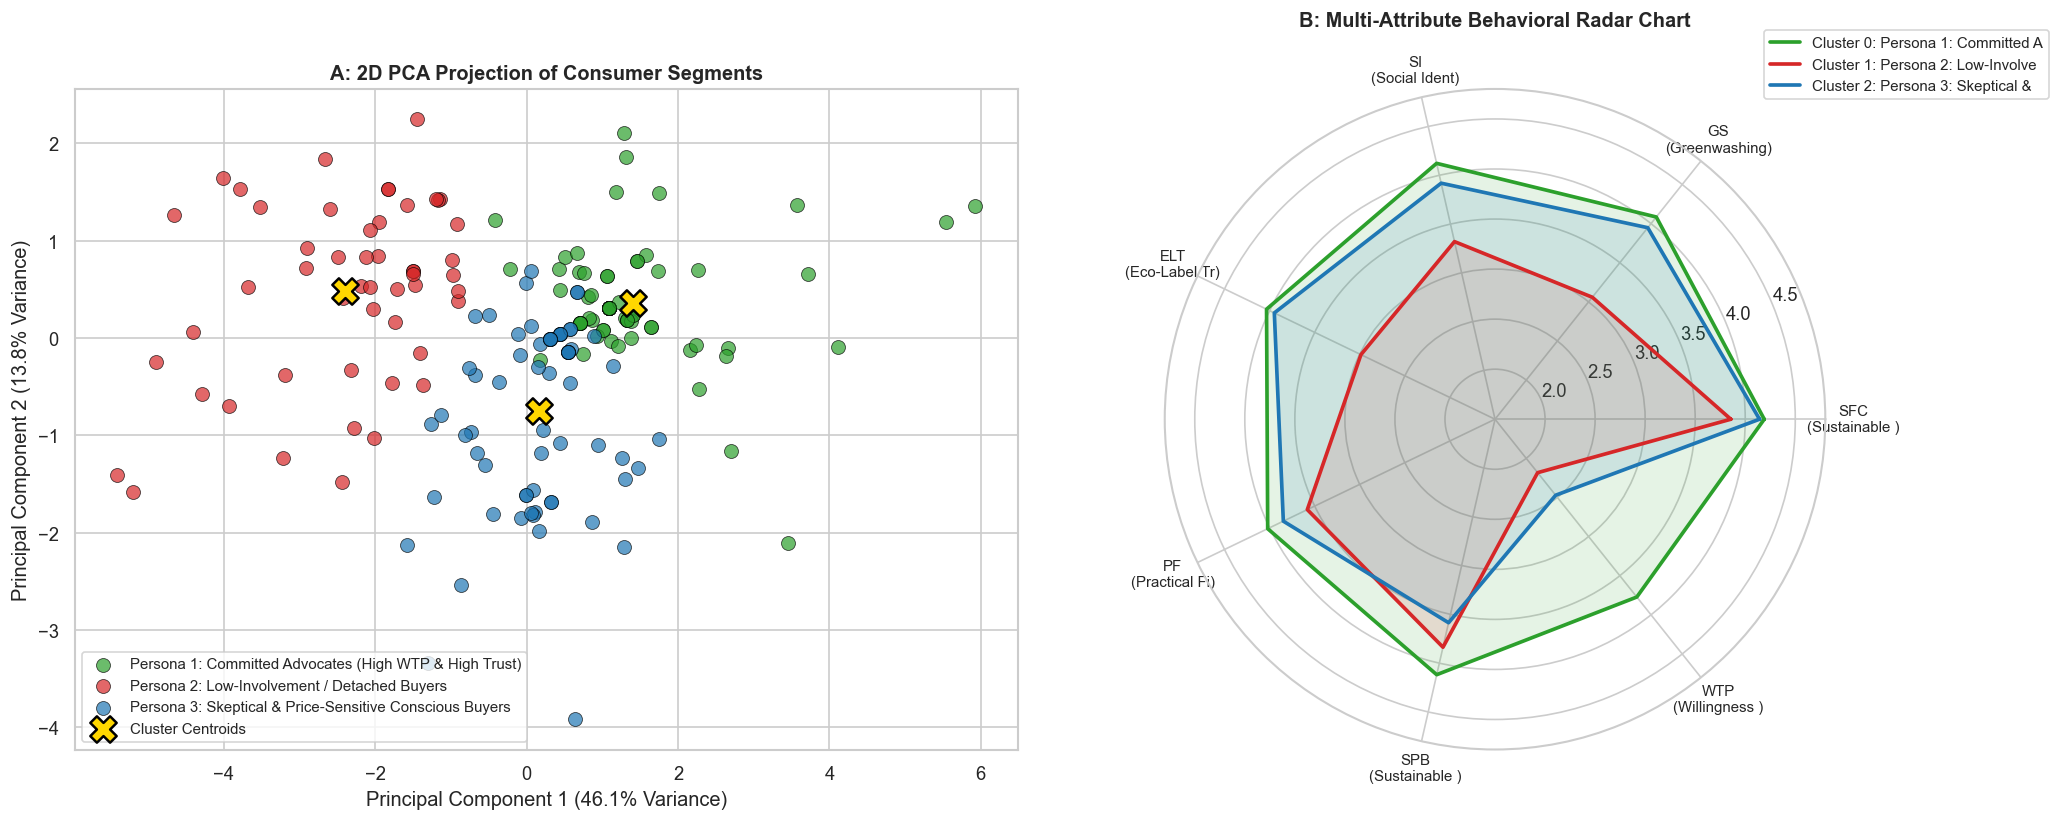

In [16]:
# ==============================================================================
# SECTION 9.2: 2D PCA PROJECTION & MULTI-ATTRIBUTE RADAR / SPIDER CHART
# ==============================================================================

# 1. 2D PCA Projection
pca_2d = PCA(n_components=2)
coords_2d = pca_2d.fit_transform(X_cluster_scaled)
df_model['PCA1'] = coords_2d[:, 0]
df_model['PCA2'] = coords_2d[:, 1]

fig = plt.figure(figsize=(18, 7))

# Subplot 1: 2D PCA Scatter
ax1 = fig.add_subplot(1, 2, 1)
colors_cluster = ['#2ca02c', '#d62728', '#1f77b4']
for c_idx in range(optimal_k):
    sub = df_model[df_model['Cluster'] == c_idx]
    ax1.scatter(sub['PCA1'], sub['PCA2'], label=persona_labels[c_idx], 
                color=colors_cluster[c_idx], alpha=0.7, s=70, edgecolors='black', lw=0.5)

# Plot Centroids
centroids_2d = pca_2d.transform(km_final.cluster_centers_)
ax1.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='X', s=250, c='gold', edgecolors='black', lw=1.5, label='Cluster Centroids')
ax1.set_title("A: 2D PCA Projection of Consumer Segments", fontweight='bold')
ax1.set_xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)")
ax1.set_ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)")
ax1.legend(loc='lower left', fontsize=9)

# Subplot 2: Multi-Attribute Radar Chart
ax2 = fig.add_subplot(1, 2, 2, polar=True)
categories = construct_cols
num_vars = len(categories)
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles_closed = angles + angles[:1]

for c_idx in range(optimal_k):
    vals = cluster_summary.loc[c_idx].values.flatten().tolist()
    vals_closed = vals + vals[:1]
    ax2.plot(angles_closed, vals_closed, linewidth=2.2, linestyle='solid', label=f"Cluster {c_idx}: {persona_labels[c_idx][:22]}", color=colors_cluster[c_idx])
    ax2.fill(angles_closed, vals_closed, color=colors_cluster[c_idx], alpha=0.12)

ax2.set_xticks(angles)
ax2.set_xticklabels([f"{c}\n({construct_definitions[c]['label'][:12]})" for c in categories], fontsize=9)
ax2.set_ylim(1.5, 4.8)
ax2.set_title("B: Multi-Attribute Behavioral Radar Chart", fontweight='bold', y=1.08)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.tight_layout()
plt.show()


=== GENDER BREAKDOWN BY CLUSTER PERSONA (%) ===


Gender,Female,Male
Persona,,
Persona 1: Committed Advocates (High WTP & High Trust),82.3,17.7
Persona 2: Low-Involvement / Detached Buyers,84.3,15.7
Persona 3: Skeptical & Price-Sensitive Conscious Buyers,80.0,20.0



=== INCOME BREAKDOWN BY CLUSTER PERSONA (%) ===


Monthly Income,"£L£e£s£s£ £t£h£a£n£ ££1£,£0£0£0£",£P£r£e£f£e£r£ £n£o£t£ £t£o£ £s£a£y£,"££1£,£0£0£0£–££1£,£9£9£9£","££2£,£0£0£0£–££2£,£9£9£9£","££3£,£0£0£0£–££3£,£9£9£9£","££4£,£0£0£0£ £o£r£ £a£b£o£v£e£"
Persona,,,,,,
Persona 1: Committed Advocates (High WTP & High Trust),73.4,6.3,11.4,8.9,0.0,0.0
Persona 2: Low-Involvement / Detached Buyers,68.6,0.0,13.7,13.7,2.0,2.0
Persona 3: Skeptical & Price-Sensitive Conscious Buyers,67.1,1.4,22.9,8.6,0.0,0.0


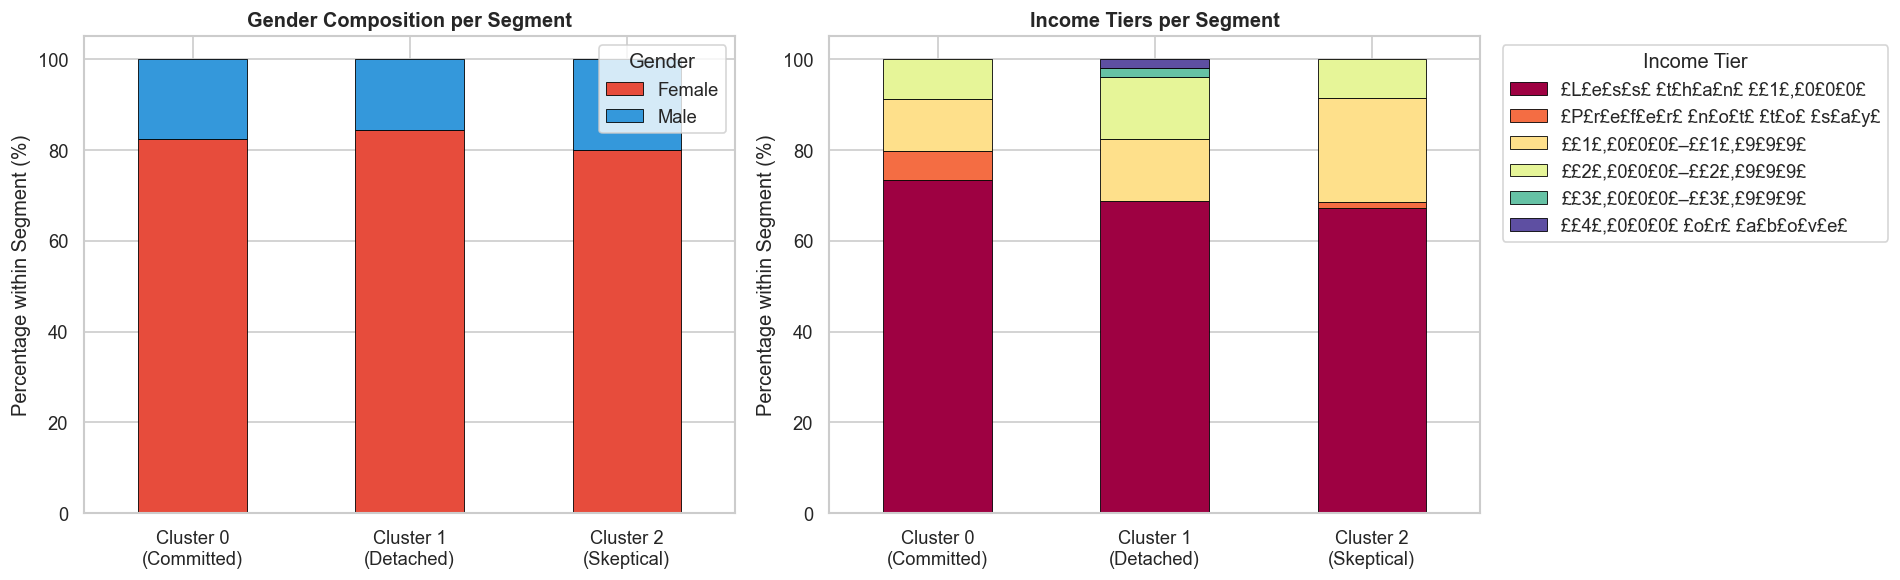

In [17]:
# ==============================================================================
# SECTION 9.3: DEMOGRAPHIC PROFILE OF CONSUMER CLUSTERS
# ==============================================================================

# Cross-tabulations
ct_gender = pd.crosstab(df_model['Persona'], df_model['Gender'], normalize='index') * 100
ct_income = pd.crosstab(df_model['Persona'], df_model['Monthly Income'], normalize='index') * 100

print("=== GENDER BREAKDOWN BY CLUSTER PERSONA (%) ===")
display(ct_gender.round(1))

print("\n=== INCOME BREAKDOWN BY CLUSTER PERSONA (%) ===")
display(ct_income.round(1))

# Visualizing Demographic Segmentation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ct_gender.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'], ax=ax1, edgecolor='black', lw=0.5)
ax1.set_title("Gender Composition per Segment", fontweight='bold')
ax1.set_ylabel("Percentage within Segment (%)")
ax1.set_xlabel("")
ax1.set_xticklabels(["Cluster 0\n(Committed)", "Cluster 1\n(Detached)", "Cluster 2\n(Skeptical)"], rotation=0)
ax1.legend(title="Gender", loc='upper right')

ct_income.plot(kind='bar', stacked=True, colormap='Spectral', ax=ax2, edgecolor='black', lw=0.5)
ax2.set_title("Income Tiers per Segment", fontweight='bold')
ax2.set_ylabel("Percentage within Segment (%)")
ax2.set_xlabel("")
ax2.set_xticklabels(["Cluster 0\n(Committed)", "Cluster 1\n(Detached)", "Cluster 2\n(Skeptical)"], rotation=0)
ax2.legend(title="Income Tier", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()
